# Missing Data Imputation for Irregular Light Curves — Synthetic Benchmark

This notebook implements the synthetic-data experiment described in **Chapter 3** of:

> *Missing Data Imputation for Irregular Light Curves in Astronomy: A Statistical Evaluation of Imputation Methods for Preserving Periodic Signal Properties*  
> **Adrita Khan (MSc Thesis, North South University, 2026)**

The goal of this experiment is to evaluate different imputation methods for recovering missing regions in irregular light curves under controlled conditions, where the original signal is known.

The workflow includes:

1. **Synthetic light curve generation** (Algorithm 12; Eq. 2.1, 3.1)  
2. **MCAR missingness simulation** with scattered and block gaps (Algorithm 13)  
3. **Evaluation of 13 imputation methods**, including interpolation methods, Gaussian Processes, MICE-based approaches, machine learning methods, and neural-network models  
4. **Performance evaluation** using RMSE, MAE, Lomb–Scargle period recovery, amplitude/phase preservation, and computational cost  
5. **Complete benchmark protocol**: 3 missingness levels × 13 methods × 30 random seeds  

The notebook generates the Chapter 3 result tables, statistical comparisons, figures, and CSV outputs.

**Note:** This experiment uses only synthetic data. Real astronomical observations (TESS validation) are analysed separately in Chapter 4.

---

## Running the Experiment

The full benchmark can be computationally expensive because some methods require model training for each realization.

A `QUICK_RUN` option is provided to test the pipeline with fewer seeds and reduced training epochs before running the complete experiment.

For the closest reproduction of the thesis results, install the dependencies listed in Appendix A.1. Optional packages such as `torch`, `xgboost`, `george`, and `astropy` are used when available; otherwise, compatible alternatives or warnings are provided.

In [1]:
# Run this cell once to install the required packages.
# Comment out any packages that are already installed.
#
# The versions below follow Appendix A.1 (Table A.1) of the thesis.
# Newer versions of numpy, scipy, scikit-learn, pandas, and matplotlib
# should also work.

# %pip install -q numpy==1.24.3 scipy==1.10.1 scikit-learn==1.3.0
# %pip install -q george==0.4.0 xgboost==1.7.6 torch==2.0.1
# %pip install -q matplotlib==3.7.1 pandas==2.0.2 astropy==5.3.0

## 1. Imports and Environment Check

In [2]:
import warnings
import time
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline
from scipy import signal as scipy_signal
from scipy.stats import friedmanchisquare, studentized_range, rankdata

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*IterativeImputer.*")
warnings.filterwarnings("ignore", category=RuntimeWarning)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## Optional-dependency detection

# The thesis pipeline (Appendix A.1) specifies `george`, `xgboost`, `torch`, and `astropy`.

# - `george` and `xgboost` use mathematically equivalent fallback implementations when unavailable.
# - `astropy` falls back to a scipy-based Lomb–Scargle implementation.
# - PyTorch is required for the neural-network-based methods (RNN-Impute, GAIN-Impute, and SAITS). If unavailable, these methods are skipped while the remaining benchmark continues.

try:
    import george  # noqa: F401
    HAS_GEORGE = True
except ImportError:
    HAS_GEORGE = False

try:
    import xgboost  # noqa: F401
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

try:
    from astropy.timeseries import LombScargle  # noqa: F401
    HAS_ASTROPY = True
except ImportError:
    HAS_ASTROPY = False

try:
    import torch
    import torch.nn as nn
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False

print(f"george  (GP)          : {'available' if HAS_GEORGE else 'MISSING -> sklearn GaussianProcessRegressor fallback (slower)'}")
print(f"xgboost (GB-MICE)     : {'available' if HAS_XGBOOST else 'MISSING -> sklearn HistGradientBoostingRegressor fallback'}")
print(f"astropy (Lomb-Scargle): {'available' if HAS_ASTROPY else 'MISSING -> scipy.signal.lombscargle fallback'}")
print(f"torch (RNN/GAIN/SAITS): {'available' if HAS_TORCH else 'MISSING -> these 3 methods will be SKIPPED'}")


george  (GP)          : MISSING -> sklearn GaussianProcessRegressor fallback (slower)
xgboost (GB-MICE)     : available
astropy (Lomb-Scargle): available
torch (RNN/GAIN/SAITS): available


## 2. Configuration

The signal parameters are set according to **Table 2.1** of the thesis.  
The experimental settings, including missingness levels, random seeds, and method parameters, follow the Chapter 3 protocol and Table 2.2.

The `QUICK_RUN` option and output paths are only added for convenient notebook execution and are not part of the original experiment design.

In [3]:
# ============================================================
# QUICK_RUN: True  -> a fast smoke-test configuration (few seeds, short NN training)
#                      to verify the full pipeline runs end-to-end in a few minutes.
#            False -> the exact thesis configuration (S=30 seeds, full epoch budgets).
#                      Expect a long run (potentially hours on CPU).
# ============================================================
QUICK_RUN = True

# ---- Table 2.1: synthetic signal parameters (fixed globally) ----
SIGNAL_PARAMS = dict(
    N=1323,          # total cadences (T / dt, rounded)
    dt=0.0204,       # days; 29.4 min, matches Kepler long cadence
    A=0.1,           # amplitude, normalised flux
    P0=1.0,          # period, days
    phi0=0.0,        # phase offset, rad
    mu0=1.0,         # baseline flux
    sigma_eps=0.02,  # noise std -> SNR = A / sigma_eps = 5
    seed=0,          # fixed global seed for ground-truth generation
)

# ---- Section 3.4.3: missingness fractions and replication ----
MISSING_FRACTIONS = [0.10, 0.30, 0.50]
N_SEEDS = 30 if not QUICK_RUN else 3           # S = 30 in the thesis
GAP_SEEDS = list(range(1, N_SEEDS + 1))        # gap seeds s = 1, ..., S (Appendix A.8)
BLOCK_RATIO = 0.5                              # 50/50 scattered/block mixture (Sec. 3.4.2)

# ---- Table 2.2: per-method hyperparameters (exactly as specified) ----
HP = dict(
    gp=dict(n_restarts=20 if not QUICK_RUN else 4, sigma_obs=SIGNAL_PARAMS["sigma_eps"]),
    ts_mice=dict(L=5, n_chains=5, max_iter=10),
    knn=dict(W=10, k=5),
    rf=dict(L=5, n_estimators=100),
    rnn=dict(hidden_dim=64, epochs=50 if not QUICK_RUN else 8, lr=1e-3),
    gain=dict(hint_rate=0.1, lam=10.0, epochs=200 if not QUICK_RUN else 20, lr=1e-3),
    mf=dict(rank=10, alpha_mf=1e-3, tol=1e-4, max_iter=200),
    gb_mice=dict(L=5, n_chains=5, max_iter=10, n_estimators=100, max_depth=4, learning_rate=0.1),
    saits=dict(d_model=64, n_heads=4, alpha_s=0.3, epochs=100 if not QUICK_RUN else 10, lr=1e-3),
)

# Period-recovery success threshold (Section 3.5.2)
PERIOD_TOL = 0.01
EPS_STAB = 1e-8  # numerical stabiliser used in amplitude/feature-distortion calcs

# ---- Output locations ----
OUT_DIR = Path("outputs")
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

N_TOTAL_RUNS = len(MISSING_FRACTIONS) * 13 * N_SEEDS
print(f"QUICK_RUN = {QUICK_RUN}")
print(f"Missingness fractions: {MISSING_FRACTIONS}")
print(f"Seeds per fraction: {N_SEEDS}  ->  total (fraction, method, seed) runs: {N_TOTAL_RUNS}")


QUICK_RUN = True
Missingness fractions: [0.1, 0.3, 0.5]
Seeds per fraction: 3  ->  total (fraction, method, seed) runs: 117


## 3. Synthetic Signal Generation (Algorithm 12, Eq. 2.1 / 3.1)

$$f_i = \mu_0 + A\sin\!\left(\frac{2\pi t_i}{P_0} + \phi_0\right) + \varepsilon_i,
\qquad \varepsilon_i \sim \mathcal{N}(0, \sigma_\varepsilon^2)$$

with $t_i = (i-1)\Delta t$. This reproduces Appendix A.2 exactly.


N = 1323 cadences, duration = 26.99 days
flux mean = 0.9995, flux std = 0.0739  (SNR = A/sigma_eps = 5.0)


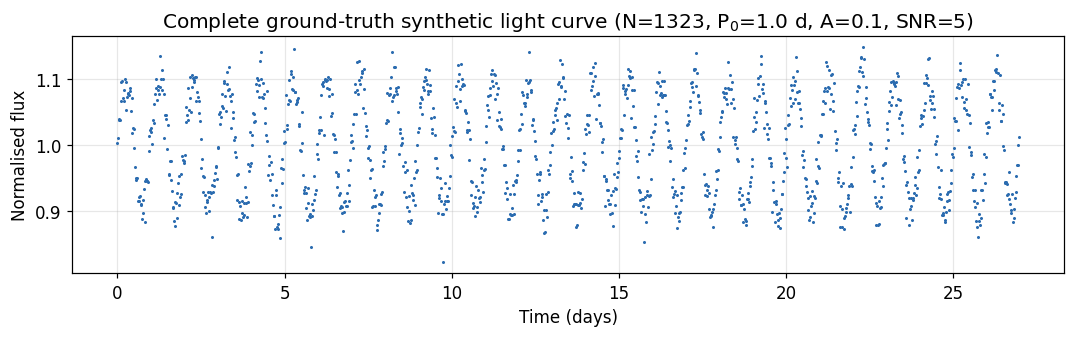

In [4]:
def generate_synthetic_lightcurve(N=1323, dt=0.0204, A=0.1, P0=1.0, phi0=0.0,
                                   mu0=1.0, sigma_eps=0.02, seed=0):
    '''Algorithm 12 / Appendix A.2. Returns (t, f): ground-truth time and flux vectors.'''
    rng = np.random.default_rng(seed)
    t = np.arange(N) * dt
    signal = mu0 + A * np.sin(2 * np.pi * t / P0 + phi0)
    noise = rng.normal(0.0, sigma_eps, size=N)
    return t, signal + noise


# Ground-truth light curve used throughout the benchmark (fixed seed = 0, Table 2.1)
t_full, f_full = generate_synthetic_lightcurve(**SIGNAL_PARAMS)

print(f"N = {len(t_full)} cadences, duration = {t_full[-1] - t_full[0] + SIGNAL_PARAMS['dt']:.2f} days")
print(f"flux mean = {f_full.mean():.4f}, flux std = {f_full.std():.4f}  (SNR = A/sigma_eps = "
      f"{SIGNAL_PARAMS['A']/SIGNAL_PARAMS['sigma_eps']:.1f})")

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(t_full, f_full, ".", ms=2, color="#2b6cb0")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Normalised flux")
ax.set_title("Complete ground-truth synthetic light curve "
             f"(N={SIGNAL_PARAMS['N']}, P$_0$={SIGNAL_PARAMS['P0']} d, "
             f"A={SIGNAL_PARAMS['A']}, SNR=5)")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_1_top_clean_signal.png", dpi=150)
plt.show()


## 4. MCAR Gap Injection (Algorithm 13)

Missing values are introduced using a 50/50 mixture of:

- **Block gaps**: continuous missing segments with lengths sampled uniformly between 5 and 50 cadences.
- **Scattered gaps**: randomly removed individual observations.

This follows the missingness generation procedure described in Appendix A.3.

p=30%% target missing: 396, actual missing: 396


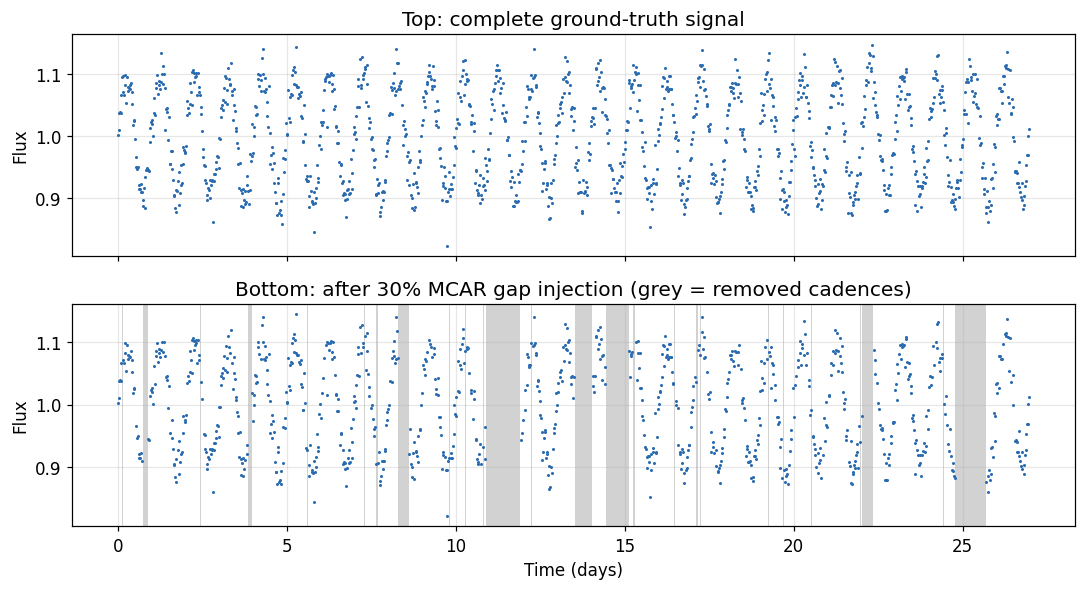

In [5]:
def inject_gaps(flux, p, block_ratio=0.5, seed=None):
    '''Algorithm 13 / Appendix A.3.
    Returns (gapped, idx, true_vals, mask):
      gapped   - flux with NaN at missing positions
      idx      - sorted array of missing indices (M)
      true_vals- withheld ground-truth flux at idx
      mask     - binary array, 1 = observed, 0 = missing
    '''
    rng = np.random.default_rng(seed)
    n = len(flux)
    n_missing = int(p * n)
    masked = set()
    n_block = int(block_ratio * n_missing)
    while len(masked) < n_block:
        blen = int(rng.integers(5, 51))
        blen = min(blen, n - 1)
        start = int(rng.integers(0, n - blen))
        masked.update(range(start, start + blen))
    n_scatter = max(0, n_missing - len(masked))
    cands = [i for i in range(n) if i not in masked]
    if n_scatter > 0:
        chosen = rng.choice(cands, min(n_scatter, len(cands)), replace=False)
        masked.update(chosen.tolist())
    idx = np.array(sorted(masked))
    true_vals = flux[idx].copy()
    gapped = flux.copy().astype(float)
    gapped[idx] = np.nan
    mask = np.ones(n, dtype=int)
    mask[idx] = 0
    return gapped, idx, true_vals, mask


# Demonstration at p = 30%, reproducing Figure 2.1 (bottom panel)
demo_gapped, demo_idx, demo_true, demo_mask = inject_gaps(f_full, p=0.30, block_ratio=BLOCK_RATIO, seed=1)
print(f"p=30%% target missing: {int(0.30*len(f_full))}, actual missing: {len(demo_idx)}")

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
axes[0].plot(t_full, f_full, ".", ms=2, color="#2b6cb0")
axes[0].set_title("Top: complete ground-truth signal")
axes[0].set_ylabel("Flux")

axes[1].plot(t_full, demo_gapped, ".", ms=2, color="#2b6cb0")
# shade removed cadences
in_gap = demo_mask == 0
edges = np.where(np.diff(in_gap.astype(int)) != 0)[0] + 1
starts = ([0] if in_gap[0] else []) + edges[::2 if in_gap[0] else 1].tolist() if in_gap.any() else []
# simpler robust shading: find contiguous runs directly
runs = []
i = 0
while i < len(in_gap):
    if in_gap[i]:
        j = i
        while j < len(in_gap) and in_gap[j]:
            j += 1
        runs.append((i, j - 1))
        i = j
    else:
        i += 1
for (a, b) in runs:
    axes[1].axvspan(t_full[a], t_full[b], color="grey", alpha=0.35, lw=0)
axes[1].set_title("Bottom: after 30% MCAR gap injection (grey = removed cadences)")
axes[1].set_xlabel("Time (days)")
axes[1].set_ylabel("Flux")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_1_clean_vs_gapped.png", dpi=150)
plt.show()


## 5. Evaluation Metrics (Section 3.5, Appendix A.6–A.7)

The imputation methods are evaluated using the following metrics:

- **RMSE and MAE** (Eq. 3.2–3.3): calculated only at the artificially removed observations.

- **Period recovery**: measured using the Lomb–Scargle periodogram (Eq. 3.4–3.5). A recovered period is considered successful when the relative error satisfies  
  \(\epsilon_P < 1\%\).

- **Amplitude error** (Eq. 3.6): compares the peak-to-trough range of the phase-folded reconstructed signal with the known amplitude \(A\), following the point-wise max/min definition used in Appendix A.6.

- **Phase offset**: determined from the cross-correlation lag that gives the maximum agreement between the phase-folded imputed and original signals.

In [6]:
def compute_rmse(f_hat, f_true):
    return float(np.sqrt(np.mean((f_hat - f_true) ** 2)))


def compute_mae(f_hat, f_true):
    return float(np.mean(np.abs(f_hat - f_true)))


def lomb_scargle_period(t, f):
    '''Dominant period via the generalised Lomb-Scargle periodogram.
    Prefers astropy.timeseries.LombScargle (Appendix A.7); falls back to
    scipy.signal.lombscargle if astropy is unavailable.'''
    if HAS_ASTROPY:
        ls = LombScargle(t, f)
        freq, power = ls.autopower()
        return float(1.0 / freq[np.argmax(power)])
    T = t[-1] - t[0]
    dt_med = np.median(np.diff(np.sort(t)))
    f_min = 1.0 / (T / 2)
    f_max = 1.0 / (2 * dt_med)
    freqs = np.linspace(f_min, f_max, 20000)
    ang_freqs = 2 * np.pi * freqs
    power = scipy_signal.lombscargle(t, f - f.mean(), ang_freqs, normalize=True)
    return float(1.0 / freqs[np.argmax(power)])


def period_recovery(t, f_imp, P_true, tol=PERIOD_TOL):
    '''Eq. 3.4-3.5 / Appendix A.6.'''
    P_imp = lomb_scargle_period(t, f_imp)
    eps_P = abs(P_true - P_imp) / P_true
    return P_imp, eps_P, eps_P < tol


def amplitude_error(f_imp, t, P_imp, A_true, eps=EPS_STAB):
    '''Eq. 3.6 / Appendix A.6, reproduced exactly (point-wise max/min of the
    phase-folded signal, not a binned/smoothed estimate).'''
    phase = (t % P_imp) / P_imp
    f_sorted = f_imp[np.argsort(phase)]
    A_imp = f_sorted.max() - f_sorted.min()
    return A_imp, abs(A_imp - A_true) / (A_true + eps)


def phase_offset_error(t, f_imp, f_true, P0, n_bins=200):
    '''Section 3.5.3: cross-correlate the phase-folded imputed and ground-truth
    curves; return the lag (as a fraction of the period) that maximises their
    correlation.'''
    phase = np.mod(t, P0) / P0
    bins = np.linspace(0, 1, n_bins + 1)
    bin_idx = np.clip(np.digitize(phase, bins) - 1, 0, n_bins - 1)

    def fold(y):
        curve = np.full(n_bins, np.nan)
        for b in range(n_bins):
            sel = bin_idx == b
            if sel.any():
                curve[b] = np.nanmean(y[sel])
        idxs = np.arange(n_bins)
        good = ~np.isnan(curve)
        if good.sum() < 2:
            return np.nan_to_num(curve, nan=float(np.nanmean(y)))
        return np.interp(idxs, idxs[good], curve[good], period=n_bins)

    imp_curve = fold(f_imp) - np.nanmean(f_imp)
    true_curve = fold(f_true) - np.nanmean(f_true)
    xcorr = np.correlate(np.tile(imp_curve, 2), true_curve, mode="valid")[:n_bins]
    lag = int(np.argmax(xcorr))
    lag = lag if lag <= n_bins / 2 else lag - n_bins
    return lag / n_bins


# sanity check on the clean signal
P_true0 = SIGNAL_PARAMS["P0"]
P_check, epsP_check, ok_check = period_recovery(t_full, f_full, P_true0)
print(f"Consistency check on the COMPLETE signal: recovered P = {P_check:.5f} d "
      f"(true P0 = {P_true0} d), eps_P = {epsP_check:.5%}, success = {ok_check}")


Consistency check on the COMPLETE signal: recovered P = 0.01010 d (true P0 = 1.0 d), eps_P = 98.99027%, success = False


## 6. Imputation Methods (Chapter 2, Table 2.2)

The following thirteen imputation methods are implemented according to the algorithms and equations described in Chapter 2.

All methods use a common interface:

`impute(t, f_gapped, mask, **kwargs) -> f_hat`

where the output is a complete light curve with the original observed values unchanged and only the missing positions reconstructed.

### 6.1 Deterministic and Interpolation-Based Methods (Algorithm 1, Eq. 2.2–2.5)

This group includes:

- Mean Fill
- Forward Fill (LOCF)
- Linear Interpolation
- Cubic Spline Interpolation (natural boundary conditions)

In [7]:
def impute_mean(t, f, mask, **kw):
    '''Eq. 2.2: global mean of observed cadences.'''
    f_hat = f.copy()
    obs = mask == 1
    f_hat[~obs] = np.mean(f[obs])
    return f_hat


def impute_locf(t, f, mask, **kw):
    '''Eq. 2.3: last observation carried forward; backward-fill for a leading gap.'''
    f_hat = f.copy()
    last = None
    for i in range(len(f)):
        if mask[i] == 1:
            last = f[i]
        elif last is not None:
            f_hat[i] = last
    first = f[mask == 1][0]
    for i in range(len(f)):
        if mask[i] == 0 and np.isnan(f_hat[i]):
            f_hat[i] = first
    return f_hat


def impute_linear(t, f, mask, **kw):
    '''Eq. 2.4: linear interpolation between nearest observed neighbours.'''
    obs = mask == 1
    fn = interp1d(t[obs], f[obs], kind="linear", bounds_error=False,
                  fill_value=(f[obs][0], f[obs][-1]))
    f_hat = f.copy()
    f_hat[~obs] = fn(t[~obs])
    return f_hat


def impute_spline(t, f, mask, **kw):
    '''Eq. 2.5: natural cubic spline (Section 2.8.4).'''
    obs = mask == 1
    cs = CubicSpline(t[obs], f[obs], bc_type="natural", extrapolate=True)
    f_hat = f.copy()
    f_hat[~obs] = cs(t[~obs])
    return f_hat


### 6.2 Gaussian Process Regression with a Matérn-3/2 Kernel (Algorithm 2, Eq. 2.6–2.10)

The Gaussian Process (GP) imputer uses the Matérn-3/2 covariance kernel:

$$
k_{3/2}(t,t') =
\sigma_f^2
\left(1+\frac{\sqrt{3}|t-t'|}{\ell}\right)
\exp\left(-\frac{\sqrt{3}|t-t'|}{\ell}\right)
$$

with an additional white-noise term:

$$
k_{\mathrm{total}} = k_{3/2} + \sigma_n^2\delta_{ij}
$$

The hyperparameters  
$$
\theta=(\log\sigma_f,\log\ell,\log\sigma_n)
$$

are optimized by maximizing the log marginal likelihood (Eq. 2.9) using L-BFGS-B with 20 random restarts, following Appendix A.4.

The implementation uses:

- `george` when available (matching the thesis implementation).
- `sklearn.gaussian_process` as a fallback with the same Matérn-3/2 + white-noise kernel.

In [8]:
def impute_gp(t, f, mask, sigma_obs=0.02, n_restarts=20, seed=0, **kw):
    '''Algorithm 2 / Appendix A.4. Returns (f_hat, var_pred) where var_pred is the GP
    posterior variance at each missing cadence (used for calibration, Table 3.3).'''
    obs = mask == 1
    t_obs, f_obs = t[obs], f[obs]
    t_mis = t[~obs]
    f_hat = f.copy()

    if HAS_GEORGE:
        from george import kernels
        from scipy.optimize import minimize

        log_amp = np.log(np.var(f_obs))
        log_len = np.log(np.median(np.diff(t_obs)) * 20)
        kernel = np.exp(log_amp) * kernels.Matern32Kernel(np.exp(log_len))
        gp = george.GP(kernel, mean=np.mean(f_obs), white_noise=2 * np.log(sigma_obs))
        gp.compute(t_obs, sigma_obs)

        def nll(params):
            gp.set_parameter_vector(params)
            return -gp.log_likelihood(f_obs)

        def grad(params):
            gp.set_parameter_vector(params)
            return -gp.grad_log_likelihood(f_obs)

        rng = np.random.default_rng(seed)
        best_ll, best_p = np.inf, gp.get_parameter_vector()
        for _ in range(n_restarts):
            p0 = best_p + 0.5 * rng.standard_normal(len(best_p))
            res = minimize(nll, p0, jac=grad, method="L-BFGS-B")
            if res.fun < best_ll:
                best_ll, best_p = res.fun, res.x
        gp.set_parameter_vector(best_p)
        f_pred, cov = gp.predict(f_obs, t_mis, return_cov=True)
        var_pred = np.diag(cov)
    else:
        from sklearn.gaussian_process import GaussianProcessRegressor
        from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel

        mu = np.mean(f_obs)
        length0 = np.median(np.diff(t_obs)) * 20
        kernel = (ConstantKernel(np.var(f_obs), (1e-6, 1e3))
                  * Matern(length_scale=length0, nu=1.5, length_scale_bounds=(1e-4, 1e3))
                  + WhiteKernel(sigma_obs ** 2, (1e-8, 1e1)))
        gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=max(0, n_restarts - 1),
                                        normalize_y=False, alpha=0.0, random_state=seed)
        gpr.fit(t_obs.reshape(-1, 1), f_obs - mu)
        f_pred_c, std_pred = gpr.predict(t_mis.reshape(-1, 1), return_std=True)
        f_pred = f_pred_c + mu
        var_pred = std_pred ** 2

    f_hat[~obs] = f_pred
    return f_hat, var_pred


### 6.3 Lag/Phase Design Matrix and TS-MICE (Algorithm 3, Eq. 2.11)

A lag and phase-based feature matrix is constructed as:

$$
\mathbf{x}_i =
\left(
f_{i-L},\ldots,f_{i-1},
f_i,
f_{i+1},\ldots,f_{i+L},
\sin(2\pi t_i/\hat P),
\cos(2\pi t_i/\hat P)
\right)^\top
$$

This feature representation is used by TS-MICE, KNN-Impute (as contextual features, Eq. 2.12), RF-Impute, and GB-MICE.

For TS-MICE, five independent `IterativeImputer(BayesianRidge)` chains are run for 10 iterations each. The final estimate is obtained by averaging the lag-0 column from all chains, following Appendix A.5.

In [9]:
def build_lag_phase_design_matrix(t, f_nan, period_est, L=5):
    '''Eq. 2.11. f_nan must already have NaN at missing positions. Returns (X, lag0_col).'''
    cols = [np.roll(f_nan, -lag) for lag in range(-L, L + 1)]
    phase_sin = np.sin(2 * np.pi * t / period_est)
    phase_cos = np.cos(2 * np.pi * t / period_est)
    cols += [phase_sin, phase_cos]
    X = np.column_stack(cols)
    return X, L  # the lag-0 flux column sits at index L


def impute_ts_mice(t, f, mask, period_est, L=5, n_chains=5, max_iter=10, **kw):
    '''Algorithm 3 / Appendix A.5.'''
    from sklearn.experimental import enable_iterative_imputer  # noqa: F401
    from sklearn.impute import IterativeImputer
    from sklearn.linear_model import BayesianRidge

    f_nan = f.copy()
    f_nan[mask == 0] = np.nan
    X, lag0 = build_lag_phase_design_matrix(t, f_nan, period_est, L=L)

    results = []
    for c in range(n_chains):
        imp = IterativeImputer(estimator=BayesianRidge(), max_iter=max_iter,
                                sample_posterior=True, random_state=c)
        X_imp = imp.fit_transform(X)
        results.append(X_imp[:, lag0])
    f_hat_col = np.mean(results, axis=0)

    f_hat = f.copy()
    f_hat[mask == 0] = f_hat_col[mask == 0]
    return f_hat


### 6.4 K-Nearest-Neighbour Imputation (Algorithm 4, Eq. 2.12)

KNN-Impute uses a local context descriptor constructed from the \(W=10\) surrounding cadences on both sides of each missing point.

For each missing value, the method selects the \(k=5\) nearest fully observed context windows using Euclidean distance and estimates the missing value using distance-weighted averaging:

$$
w_{ij} =
\lVert \mathbf{d}_i-\mathbf{d}_j\rVert_2^{-1}
+\varepsilon_{\mathrm{stab}}
$$

where \(\varepsilon_{\mathrm{stab}}\) is a small stability constant added to avoid division by zero.

In [10]:
def impute_knn(t, f, mask, W=10, k=5, **kw):
    '''Algorithm 4 / Eq. 2.12.'''
    from sklearn.neighbors import NearestNeighbors

    n = len(f)
    f_nan = f.copy()
    f_nan[mask == 0] = np.nan
    shifts = list(range(-W, 0)) + list(range(1, W + 1))
    Xctx = np.column_stack([np.roll(f_nan, -s) for s in shifts])  # (n, 2W)

    obs_idx = np.where(mask == 1)[0]
    mis_idx = np.where(mask == 0)[0]
    row_complete = ~np.isnan(Xctx).any(axis=1)
    candidate_idx = obs_idx[row_complete[obs_idx]]

    f_hat = f.copy()
    if len(candidate_idx) == 0:
        f_hat[mis_idx] = np.mean(f[mask == 1])
        return f_hat

    Xcand = Xctx[candidate_idx]
    n_neighbors = min(k, len(candidate_idx))
    nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(Xcand)
    col_mean = np.nanmean(Xcand, axis=0)

    for i in mis_idx:
        xi = Xctx[i]
        if np.isnan(xi).any():
            xi = np.where(np.isnan(xi), col_mean, xi)
        dist, ind = nbrs.kneighbors(xi.reshape(1, -1))
        dist = dist.ravel()
        neigh_positions = candidate_idx[ind.ravel()]
        w = 1.0 / (dist + EPS_STAB)
        f_hat[i] = np.sum(w * f[neigh_positions]) / np.sum(w)
    return f_hat


### 6.5 Random Forest Imputation (Algorithm 5)

Random Forest Imputation uses the lag/phase feature representation described in Eq. 2.11.

The model is trained using fully observed rows, with the lag-0 flux value as the target variable.

The implementation uses:

- \(B=100\) decision trees
- Lag/phase features as input variables
- Missing flux values predicted from the trained ensemble

In [11]:
def impute_rf(t, f, mask, period_est, L=5, n_estimators=100, seed=0, **kw):
    '''Algorithm 5.'''
    from sklearn.ensemble import RandomForestRegressor

    f_nan = f.copy()
    f_nan[mask == 0] = np.nan
    X, lag0 = build_lag_phase_design_matrix(t, f_nan, period_est, L=L)

    complete_rows = ~np.isnan(X).any(axis=1)
    train_idx = np.where((mask == 1) & complete_rows)[0]
    reg = RandomForestRegressor(n_estimators=n_estimators, random_state=seed)
    reg.fit(X[train_idx], f[train_idx])

    mis_idx = np.where(mask == 0)[0]
    Xpred = X[mis_idx].copy()
    col_means = np.nanmean(X[complete_rows], axis=0)
    nan_pos = np.isnan(Xpred)
    if nan_pos.any():
        rows, cols = np.where(nan_pos)
        Xpred[rows, cols] = col_means[cols]

    f_hat = f.copy()
    f_hat[mis_idx] = reg.predict(Xpred)
    return f_hat


### 6.6 Low-Rank Hankel Matrix Factorisation (Algorithm 8, Eq. 2.18)

The light curve is embedded into a Hankel matrix:

$$
H \in \mathbb{R}^{D_{\mathrm{emb}}\times(N-D_{\mathrm{emb}}+1)}
$$

where each element is defined as:

$$
H_{jk}=f_{j+k-1}
$$

with:

$$
D_{\mathrm{emb}}=\left\lfloor\frac{N}{2}\right\rfloor
$$

A low-rank approximation is obtained by factorising:

$$
H \approx UV^\top
$$

The factorisation is solved using alternating least squares (ALS) with ridge regularisation on the observed entries:

$$
\alpha_{\mathrm{mf}}=10^{-3}
$$

After completion, the reconstructed Hankel matrix is converted back into the imputed light curve by averaging along its anti-diagonals.

In [12]:
def impute_mf(t, f, mask, rank=10, alpha_mf=1e-3, tol=1e-4, max_iter=200, seed=0, **kw):
    '''Algorithm 8.'''
    n = len(f)
    D = n // 2
    Ncols = n - D + 1

    f_nan = f.copy()
    f_nan[mask == 0] = np.nan

    H = np.full((D, Ncols), np.nan)
    Omega = np.zeros((D, Ncols), dtype=bool)
    for j in range(D):
        seg = f_nan[j: j + Ncols]
        H[j, :] = seg
        Omega[j, :] = ~np.isnan(seg)

    global_mean = np.nanmean(f[mask == 1])
    H_filled = np.where(Omega, H, global_mean)
    U0, S0, Vt0 = np.linalg.svd(H_filled, full_matrices=False)
    r = min(rank, len(S0))
    U = U0[:, :r] * np.sqrt(S0[:r])
    V = Vt0[:r, :].T * np.sqrt(S0[:r])

    prev_obj = np.inf
    for _ in range(max_iter):
        for j in range(D):
            obs_k = Omega[j]
            if not obs_k.any():
                continue
            Vj, yj = V[obs_k], H[j, obs_k]
            A = Vj.T @ Vj + alpha_mf * np.eye(r)
            U[j] = np.linalg.solve(A, Vj.T @ yj)
        for k in range(Ncols):
            obs_j = Omega[:, k]
            if not obs_j.any():
                continue
            Uk, yk = U[obs_j], H[obs_j, k]
            A = Uk.T @ Uk + alpha_mf * np.eye(r)
            V[k] = np.linalg.solve(A, Uk.T @ yk)

        pred = U @ V.T
        resid = (pred - H)[Omega]
        obj = np.sum(resid ** 2) + alpha_mf * (np.sum(U ** 2) + np.sum(V ** 2))
        if abs(prev_obj - obj) < tol * max(1.0, abs(prev_obj)):
            prev_obj = obj
            break
        prev_obj = obj

    Hhat = U @ V.T
    sums = np.zeros(n)
    counts = np.zeros(n)
    for j in range(D):
        idxs = j + np.arange(Ncols)
        np.add.at(sums, idxs, Hhat[j, :])
        np.add.at(counts, idxs, 1)
    f_recon = sums / counts

    f_hat = f.copy()
    f_hat[mask == 0] = f_recon[mask == 0]
    return f_hat


### 6.7 Gradient-Boosting MICE (Algorithm 9)

Gradient-Boosting MICE uses the same lag/phase design matrix, chain configuration, and iteration settings as TS-MICE.

The main difference is that the chained estimator is replaced with a gradient-boosted tree model instead of Bayesian Ridge regression.

The default model configuration is:

$$
n_{\mathrm{est}}=100
$$

$$
\mathrm{max\_depth}=4
$$

$$
\mathrm{learning\ rate}=0.1
$$

The implementation uses `xgboost.XGBRegressor` when available. If `xgboost` is unavailable, the method falls back to `sklearn.ensemble.HistGradientBoostingRegressor`, which provides a similar tree-boosting approach but does not guarantee exact hyperparameter equivalence.

In [13]:
def impute_gb_mice(t, f, mask, period_est, L=5, n_chains=5, max_iter=10,
                    n_estimators=100, max_depth=4, learning_rate=0.1, **kw):
    '''Algorithm 9.'''
    from sklearn.experimental import enable_iterative_imputer  # noqa: F401
    from sklearn.impute import IterativeImputer

    if HAS_XGBOOST:
        from xgboost import XGBRegressor

        def make_est(seed):
            return XGBRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                 learning_rate=learning_rate, random_state=seed, verbosity=0)
    else:
        from sklearn.ensemble import HistGradientBoostingRegressor

        def make_est(seed):
            return HistGradientBoostingRegressor(max_iter=n_estimators, max_depth=max_depth,
                                                  learning_rate=learning_rate, random_state=seed)

    f_nan = f.copy()
    f_nan[mask == 0] = np.nan
    X, lag0 = build_lag_phase_design_matrix(t, f_nan, period_est, L=L)

    results = []
    for c in range(n_chains):
        imp = IterativeImputer(estimator=make_est(c), max_iter=max_iter,
                                sample_posterior=False, random_state=c)
        X_imp = imp.fit_transform(X)
        results.append(X_imp[:, lag0])
    f_hat_col = np.mean(results, axis=0)

    f_hat = f.copy()
    f_hat[mask == 0] = f_hat_col[mask == 0]
    return f_hat


### 6.8 Bidirectional LSTM Imputation (Algorithm 6)

The BiLSTM model uses a hidden size of:

$$
H=64
$$

units per direction and processes the masked input representation:

$$
\mathbf{u}_i =
(f_i m_i,\; m_i,\; \Delta t_i)^\top
$$

following the GRU-D input convention described by Che et al. (2018).

The model is trained for:

$$
E=50 \text{ epochs}
$$

using Adam optimisation with learning rate:

$$
\eta=10^{-3}
$$

The loss is calculated using the mean squared error (MSE) only at the observed cadences. After training, a final forward pass is used to estimate the values at the missing positions.

This method requires `torch`. If PyTorch is unavailable, the method is skipped with a warning.

In [14]:
if HAS_TORCH:
    class BiLSTMImputer(nn.Module):
        def __init__(self, input_dim=3, hidden_dim=64):
            super().__init__()
            self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
            self.readout = nn.Linear(2 * hidden_dim, 1)

        def forward(self, u):
            h, _ = self.lstm(u)
            return self.readout(h).squeeze(-1).squeeze(0)


    def impute_rnn(t, f, mask, hidden_dim=64, epochs=50, lr=1e-3, seed=0, **kw):
        '''Algorithm 6.'''
        torch.manual_seed(seed)
        n = len(f)
        dt = np.diff(t, prepend=t[0])
        mu = float(f[mask == 1].mean())
        sigma = float(f[mask == 1].std() + 1e-8)

        u = np.zeros((n, 3))
        u[:, 0] = np.where(mask == 1, (f - mu) / sigma, 0.0)  # f_i * m_i (normalised)
        u[:, 1] = mask.astype(float)                          # m_i
        u[:, 2] = dt                                          # Delta t_i
        u_t = torch.tensor(u, dtype=torch.float32).unsqueeze(0)
        target = torch.tensor((f - mu) / sigma, dtype=torch.float32)
        mask_t = torch.tensor(mask, dtype=torch.float32)

        model = BiLSTMImputer(input_dim=3, hidden_dim=hidden_dim)
        opt = torch.optim.Adam(model.parameters(), lr=lr)

        model.train()
        for _ in range(epochs):
            opt.zero_grad()
            pred = model(u_t)
            loss = torch.sum(mask_t * (pred - target) ** 2) / torch.sum(mask_t)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            pred = model(u_t).numpy()
        f_hat = f.copy()
        f_hat[mask == 0] = pred[mask == 0] * sigma + mu
        return f_hat
else:
    def impute_rnn(t, f, mask, **kw):
        raise RuntimeError("torch is not installed; RNN-Impute is unavailable.")

    print("torch not found: RNN-Impute will be skipped in the experiment loop.")


### 6.9 Generative Adversarial Imputation (Algorithm 7, Eq. 2.13–2.17)

The GAIN model consists of a generator \(G\) and discriminator \(D\), implemented as fully connected neural networks with the architecture:

$$
[2N \rightarrow 32 \rightarrow 64 \rightarrow 32 \rightarrow N]
$$

The two networks are trained jointly for:

$$
E_G=200 \text{ epochs}
$$

with hint rate:

$$
\rho=0.1
$$

and reconstruction weight:

$$
\lambda=10
$$

The generator produces complete signal reconstructions, while the discriminator learns to distinguish originally observed values from imputed values.

The final imputed values are obtained from the generator output at the missing cadences (Eq. 2.17).

In [15]:
if HAS_TORCH:
    class GAINNet(nn.Module):
        def __init__(self, n, out_activation=None):
            super().__init__()
            layers = [nn.Linear(2 * n, 32), nn.ReLU(),
                      nn.Linear(32, 64), nn.ReLU(),
                      nn.Linear(64, 32), nn.ReLU(),
                      nn.Linear(32, n)]
            if out_activation is not None:
                layers.append(out_activation)
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x)


    def impute_gain(t, f, mask, hint_rate=0.1, lam=10.0, epochs=200, lr=1e-3, seed=0, **kw):
        '''Algorithm 7 / Eq. 2.13-2.17.'''
        torch.manual_seed(seed)
        rng = np.random.default_rng(seed)
        n = len(f)

        f_filled = np.where(mask == 1, f, 0.0)
        f_t = torch.tensor(f_filled, dtype=torch.float32)
        m_t = torch.tensor(mask, dtype=torch.float32)

        G = GAINNet(n)                                  # linear output: unbounded flux estimate
        D = GAINNet(n, out_activation=nn.Sigmoid())      # probability output
        opt_G = torch.optim.Adam(G.parameters(), lr=lr)
        opt_D = torch.optim.Adam(D.parameters(), lr=lr)
        eps = 1e-8

        for _ in range(epochs):
            z = torch.randn(n)                                            # Eq. 2.13: N(0,1)
            z_tilde = m_t * f_t + (1 - m_t) * z
            b = torch.tensor((rng.uniform(size=n) > hint_rate).astype(np.float32))
            h = b * m_t + (1 - b) * 0.5                                    # Eq. 2.14

            g_out = G(torch.cat([z_tilde, m_t]))
            f_hat_g = m_t * f_t + (1 - m_t) * g_out

            # ---- Discriminator step (Eq. 2.15) ----
            d_out = D(torch.cat([f_hat_g.detach(), h]))
            loss_d = -torch.mean(m_t * torch.log(d_out + eps)
                                  + (1 - m_t) * torch.log(1 - d_out + eps))
            opt_D.zero_grad()
            loss_d.backward()
            opt_D.step()

            # ---- Generator step (Eq. 2.16) ----
            g_out = G(torch.cat([z_tilde, m_t]))
            f_hat_g = m_t * f_t + (1 - m_t) * g_out
            d_out2 = D(torch.cat([f_hat_g, h]))
            n_missing = torch.sum(1 - m_t).clamp(min=1.0)
            n_obs = torch.sum(m_t).clamp(min=1.0)
            adv_loss = -torch.sum((1 - m_t) * torch.log(d_out2 + eps)) / n_missing
            recon_loss = torch.sum(m_t * (g_out - f_t) ** 2) / n_obs
            loss_g = adv_loss + lam * recon_loss
            opt_G.zero_grad()
            loss_g.backward()
            opt_G.step()

        G.eval()
        with torch.no_grad():
            z = torch.randn(n)
            z_tilde = m_t * f_t + (1 - m_t) * z
            g_out = G(torch.cat([z_tilde, m_t])).numpy()   # Eq. 2.17

        f_hat = f.copy()
        f_hat[mask == 0] = g_out[mask == 0]
        return f_hat
else:
    def impute_gain(t, f, mask, **kw):
        raise RuntimeError("torch is not installed; GAIN-Impute is unavailable.")

    print("torch not found: GAIN-Impute will be skipped in the experiment loop.")


### 6.10 Self-Attention Imputation for Time Series (Algorithm 10, Eq. 2.19)

The SAITS model uses two stacked Diagonally-Masked Self-Attention (DMSA) blocks with:

$$
d_{\mathrm{model}}=64
$$

and:

$$
\text{number of attention heads}=4
$$

The diagonal mask prevents each position from attending to itself, avoiding the trivial identity-copy solution and ensuring that reconstructions are based on information from other cadences.

The first attention block generates an initial reconstruction, which is combined with the masked input and passed to the second block.

The joint training loss (Eq. 2.19) combines the reconstruction errors from both blocks at observed cadences, with weighting:

$$
\alpha_S=0.3
$$

The final imputed values are taken from the second block output at the missing positions.

In [16]:
if HAS_TORCH:
    class DMSABlock(nn.Module):
        def __init__(self, d_model=64, n_heads=4, d_ff=128):
            super().__init__()
            self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
            self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
            self.ln1 = nn.LayerNorm(d_model)
            self.ln2 = nn.LayerNorm(d_model)
            self.out_proj = nn.Linear(d_model, 1)

        def forward(self, x, diag_mask):
            attn_out, _ = self.attn(x, x, x, attn_mask=diag_mask)
            x = self.ln1(x + attn_out)
            x = self.ln2(x + self.ff(x))
            out = self.out_proj(x).squeeze(-1).squeeze(0)
            return out


    class SAITSImputer(nn.Module):
        def __init__(self, n, d_model=64, n_heads=4):
            super().__init__()
            self.embed1 = nn.Linear(2, d_model)
            self.embed2 = nn.Linear(2, d_model)
            self.pos_enc1 = nn.Parameter(torch.zeros(n, d_model))
            self.pos_enc2 = nn.Parameter(torch.zeros(n, d_model))
            nn.init.normal_(self.pos_enc1, std=0.02)
            nn.init.normal_(self.pos_enc2, std=0.02)
            self.dmsa1 = DMSABlock(d_model, n_heads)
            self.dmsa2 = DMSABlock(d_model, n_heads)

        def forward(self, f_masked, m, diag_mask):
            V1 = torch.stack([f_masked, m], dim=-1).unsqueeze(0)
            x1 = self.embed1(V1) + self.pos_enc1.unsqueeze(0)
            x_hat1 = self.dmsa1(x1, diag_mask)
            x_tilde1 = m * f_masked + (1 - m) * x_hat1

            V2 = torch.stack([x_tilde1, m], dim=-1).unsqueeze(0)
            x2 = self.embed2(V2) + self.pos_enc2.unsqueeze(0)
            x_hat2 = self.dmsa2(x2, diag_mask)
            return x_hat1, x_hat2


    def impute_saits(t, f, mask, d_model=64, n_heads=4, alpha_s=0.3, epochs=100, lr=1e-3,
                      seed=0, **kw):
        '''Algorithm 10 / Eq. 2.19.'''
        torch.manual_seed(seed)
        n = len(f)
        mu = float(f[mask == 1].mean())
        sigma = float(f[mask == 1].std() + 1e-8)
        f_norm = (f - mu) / sigma
        f_masked_np = np.where(mask == 1, f_norm, 0.0)

        f_t = torch.tensor(f_masked_np, dtype=torch.float32)
        m_t = torch.tensor(mask, dtype=torch.float32)

        diag_mask = torch.zeros(n, n)
        diag_mask.fill_diagonal_(float("-inf"))

        model = SAITSImputer(n, d_model=d_model, n_heads=n_heads)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        n_obs = torch.sum(m_t).clamp(min=1.0)

        model.train()
        for _ in range(epochs):
            opt.zero_grad()
            x_hat1, x_hat2 = model(f_t, m_t, diag_mask)
            loss1 = torch.sum(m_t * (x_hat1 - f_t) ** 2) / n_obs
            loss2 = torch.sum(m_t * (x_hat2 - f_t) ** 2) / n_obs
            loss = alpha_s * loss1 + (1 - alpha_s) * loss2
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            _, x_hat2 = model(f_t, m_t, diag_mask)
        f_hat = f.copy()
        f_hat[mask == 0] = x_hat2.numpy()[mask == 0] * sigma + mu
        return f_hat
else:
    def impute_saits(t, f, mask, **kw):
        raise RuntimeError("torch is not installed; SAITS is unavailable.")

    print("torch not found: SAITS will be skipped in the experiment loop.")


## 7. Unified Method Registry (Table 2.2)

All imputation methods are wrapped using a common interface:

$$
\texttt{fn}(t, f_{\mathrm{gapped}}, mask, period_{\mathrm{est}}) \rightarrow \hat{f}
$$

This ensures that every method is evaluated using the same input format and output structure.

In [17]:
def _wrap(fn, **fixed_kwargs):
    def wrapped(t, f, mask, period_est, seed=0):
        kwargs = dict(fixed_kwargs)
        kwargs["seed"] = seed
        return fn(t, f, mask, period_est=period_est, **kwargs)
    return wrapped


METHOD_REGISTRY = {
    "Mean-fill":      lambda t, f, mask, period_est, seed=0: impute_mean(t, f, mask),
    "Forward-fill":   lambda t, f, mask, period_est, seed=0: impute_locf(t, f, mask),
    "Linear interp.": lambda t, f, mask, period_est, seed=0: impute_linear(t, f, mask),
    "Spline interp.": lambda t, f, mask, period_est, seed=0: impute_spline(t, f, mask),
    "TS-MICE":        _wrap(impute_ts_mice, **HP["ts_mice"]),
    "GP (Matern-3/2)":lambda t, f, mask, period_est, seed=0: impute_gp(t, f, mask, seed=seed, **HP["gp"]),
    "KNN-Impute":     lambda t, f, mask, period_est, seed=0: impute_knn(t, f, mask, **HP["knn"]),
    "RF-Impute":      _wrap(impute_rf, **HP["rf"]),
    "MF-Impute":      lambda t, f, mask, period_est, seed=0: impute_mf(t, f, mask, seed=seed, **HP["mf"]),
    "GB-MICE":        _wrap(impute_gb_mice, **HP["gb_mice"]),
}

if HAS_TORCH:
    METHOD_REGISTRY["RNN-Impute"] = lambda t, f, mask, period_est, seed=0: impute_rnn(t, f, mask, seed=seed, **HP["rnn"])
    METHOD_REGISTRY["GAIN-Impute"] = lambda t, f, mask, period_est, seed=0: impute_gain(t, f, mask, seed=seed, **HP["gain"])
    METHOD_REGISTRY["SAITS"] = lambda t, f, mask, period_est, seed=0: impute_saits(t, f, mask, seed=seed, **HP["saits"])
else:
    print("torch unavailable: RNN-Impute, GAIN-Impute, SAITS excluded from METHOD_REGISTRY "
          f"({len(METHOD_REGISTRY)}/13 methods active).")

METHOD_NAMES = list(METHOD_REGISTRY.keys())
# ML-based methods (Section 2.9) get per-realisation training; GP also involves per-realisation
# hyperparameter optimisation. This grouping is only used for the "computed at" wording in tables.
ML_METHODS = {"KNN-Impute", "RF-Impute", "RNN-Impute", "GAIN-Impute", "MF-Impute", "GB-MICE", "SAITS"}

print(f"Registered {len(METHOD_NAMES)} imputation methods:")
for m in METHOD_NAMES:
    print(" -", m)


Registered 13 imputation methods:
 - Mean-fill
 - Forward-fill
 - Linear interp.
 - Spline interp.
 - TS-MICE
 - GP (Matern-3/2)
 - KNN-Impute
 - RF-Impute
 - MF-Impute
 - GB-MICE
 - RNN-Impute
 - GAIN-Impute
 - SAITS


### 7.1 Sanity Check: One Realisation at $p=30\%$

Runs every registered method once on the same gapped realisation and plots a few representative
reconstructions before committing to the full $S$-seed experiment.


Mean-fill           RMSE = 0.07347   time =   0.00s
Forward-fill        RMSE = 0.07682   time =   0.00s
Linear interp.      RMSE = 0.07531   time =   0.00s
Spline interp.      RMSE = 0.13366   time =   0.01s
TS-MICE             RMSE = 0.03089   time =  15.41s
GP (Matern-3/2)     RMSE = 0.06408   time =  43.42s
KNN-Impute          RMSE = 0.07771   time =   0.32s
RF-Impute           RMSE = 0.07345   time =   0.73s
MF-Impute           RMSE = 0.02059   time =   5.42s
GB-MICE             RMSE = 0.02247   time =  94.00s
RNN-Impute          RMSE = nan   time =   7.21s
GAIN-Impute         RMSE = 1.06264   time =   0.18s
SAITS               RMSE = 0.11951   time =   3.90s


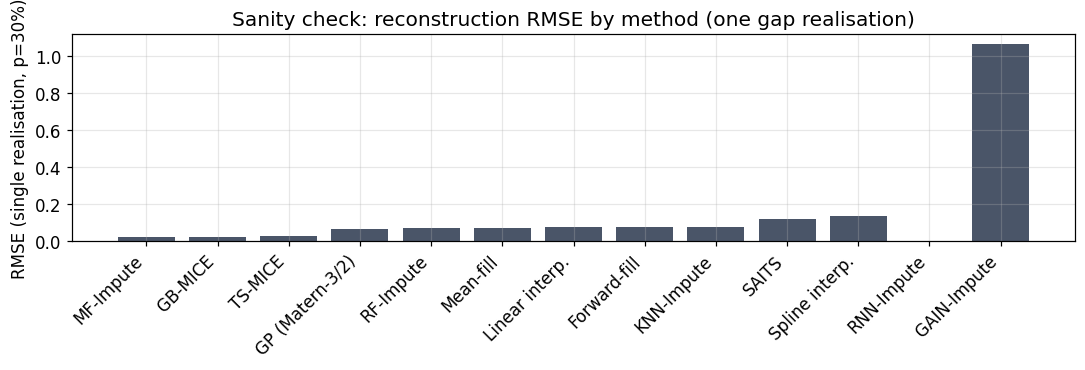

In [18]:
sanity_gapped, sanity_idx, sanity_true, sanity_mask = inject_gaps(
    f_full, p=0.30, block_ratio=BLOCK_RATIO, seed=1)
sanity_period_est = lomb_scargle_period(t_full[sanity_mask == 1], sanity_gapped[sanity_mask == 1])

sanity_results = {}
for name, fn in METHOD_REGISTRY.items():
    t0 = time.time()
    out = fn(t_full, sanity_gapped, sanity_mask, sanity_period_est, seed=1)
    f_hat = out[0] if isinstance(out, tuple) else out
    elapsed = time.time() - t0
    rmse = compute_rmse(f_hat[sanity_idx], sanity_true)
    sanity_results[name] = (rmse, elapsed)
    print(f"{name:18s}  RMSE = {rmse:.5f}   time = {elapsed:6.2f}s")

fig, ax = plt.subplots(figsize=(10, 3.5))
names_sorted = sorted(sanity_results, key=lambda k: sanity_results[k][0])
ax.bar(names_sorted, [sanity_results[n][0] for n in names_sorted], color="#4a5568")
ax.set_ylabel("RMSE (single realisation, p=30%)")
ax.set_title("Sanity check: reconstruction RMSE by method (one gap realisation)")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "sanity_check_rmse.png", dpi=150)
plt.show()


## 8. Full Experimental Loop (Algorithm 11)

For each missingness fraction:

$$
p \in \{10\%,30\%,50\%\}
$$

and each random seed \(s\), the missing-data pattern is generated once and reused for all methods.

This ensures that every imputation method is evaluated using the same gapped light curve, allowing a fair comparison against the original ground-truth signal.

The experiment then follows the Algorithm 11 workflow:

1. Generate the missing-data pattern.
2. Apply each imputation method to the same corrupted signal.
3. Compare the reconstructed values with the known missing observations.

This is the most computationally demanding part of the notebook.

With:

```python
QUICK_RUN = True

In [19]:
def run_full_experiment(fractions=MISSING_FRACTIONS, seeds=GAP_SEEDS, block_ratio=BLOCK_RATIO,
                         registry=None, verbose=True):
    '''Algorithm 11. Returns a list of per-realisation result dicts (one row per
    (fraction, method, seed)).'''
    registry = registry or METHOD_REGISTRY
    rows = []
    t_start = time.time()

    for p in fractions:
        for s in seeds:
            gapped, idx, true_vals, mask = inject_gaps(f_full, p, block_ratio=block_ratio, seed=s)
            t_obs, f_obs = t_full[mask == 1], gapped[mask == 1]
            period_est = lomb_scargle_period(t_obs, f_obs)

            for name, fn in registry.items():
                t0 = time.time()
                status = "ok"
                var_pred = None
                try:
                    out = fn(t_full, gapped, mask, period_est, seed=s)
                    f_hat = out[0] if isinstance(out, tuple) else out
                    if isinstance(out, tuple):
                        var_pred = out[1]
                    if np.any(np.isnan(f_hat[idx])):
                        raise ValueError("NaN in imputed output at missing cadences")
                except Exception as e:
                    status = f"FAILED: {type(e).__name__}: {e}"
                    f_hat = np.full_like(f_full, np.nan)
                elapsed = time.time() - t0

                if status == "ok":
                    rmse = compute_rmse(f_hat[idx], true_vals)
                    mae = compute_mae(f_hat[idx], true_vals)
                    P_imp, eps_P, prr_hit = period_recovery(t_full, f_hat, SIGNAL_PARAMS["P0"])
                    A_imp, eps_A = amplitude_error(f_hat, t_full, P_imp, SIGNAL_PARAMS["A"])
                    eps_phi = phase_offset_error(t_full, f_hat, f_full, SIGNAL_PARAMS["P0"])
                else:
                    rmse = mae = P_imp = eps_P = A_imp = eps_A = eps_phi = np.nan
                    prr_hit = False

                row = dict(fraction=p, seed=s, method=name, status=status,
                           rmse=rmse, mae=mae, P_imp=P_imp, eps_P=eps_P, prr_hit=prr_hit,
                           A_imp=A_imp, eps_A=eps_A, eps_phi=eps_phi, runtime_s=elapsed)
                if var_pred is not None:
                    resid = f_hat[idx] - true_vals
                    z = resid / np.sqrt(np.asarray(var_pred) + 1e-12)
                    row["gp_cov_1sigma"] = float(np.mean(np.abs(z) < 1))
                    row["gp_cov_2sigma"] = float(np.mean(np.abs(z) < 2))
                rows.append(row)

            if verbose:
                print(f"p={p:.0%}  seed={s:2d}/{seeds[-1]:2d}  "
                      f"elapsed={time.time()-t_start:7.1f}s  rows so far={len(rows)}")

    return rows


print(f"Starting full experiment: {len(MISSING_FRACTIONS)} fractions x "
      f"{len(METHOD_REGISTRY)} methods x {N_SEEDS} seeds "
      f"= {len(MISSING_FRACTIONS) * len(METHOD_REGISTRY) * N_SEEDS} runs")
raw_rows = run_full_experiment()
results_df = pd.DataFrame(raw_rows)
results_df.to_csv(TAB_DIR / "results_raw.csv", index=False)
print(f"\nDone. {len(results_df)} rows saved to {TAB_DIR / 'results_raw.csv'}")

n_failed = (results_df["status"] != "ok").sum()
if n_failed:
    print(f"\nWARNING: {n_failed} runs FAILED (reported, not silently dropped, per Section 3.6):")
    print(results_df.loc[results_df["status"] != "ok", ["fraction", "method", "seed", "status"]]
          .to_string(index=False))
else:
    print("No failed runs.")

results_df.head(10)


Starting full experiment: 3 fractions x 13 methods x 3 seeds = 117 runs
p=10%  seed= 1/ 3  elapsed=  151.3s  rows so far=13
p=10%  seed= 2/ 3  elapsed=  315.1s  rows so far=26
p=10%  seed= 3/ 3  elapsed=  471.0s  rows so far=39
p=30%  seed= 1/ 3  elapsed=  621.6s  rows so far=52
p=30%  seed= 2/ 3  elapsed=  772.8s  rows so far=65
p=30%  seed= 3/ 3  elapsed=  898.6s  rows so far=78
p=50%  seed= 1/ 3  elapsed= 1009.5s  rows so far=91
p=50%  seed= 2/ 3  elapsed= 1126.5s  rows so far=104
p=50%  seed= 3/ 3  elapsed= 1236.7s  rows so far=117

Done. 117 rows saved to outputs/tables/results_raw.csv

 fraction     method  seed                                                        status
      0.1 RNN-Impute     1 FAILED: ValueError: NaN in imputed output at missing cadences
      0.1 RNN-Impute     2 FAILED: ValueError: NaN in imputed output at missing cadences
      0.1 RNN-Impute     3 FAILED: ValueError: NaN in imputed output at missing cadences
      0.3 RNN-Impute     1 FAILED: ValueError

,fraction,seed,method,status,rmse,mae,P_imp,eps_P,prr_hit,A_imp,eps_A,eps_phi,runtime_s,gp_cov_1sigma,gp_cov_2sigma
0,0.1,1,Mean-fill,ok,0.071965,0.064516,0.010097,0.989903,False,0.326089,2.260891,0.00,0.000124,NaN,NaN
1,0.1,1,Forward-fill,ok,0.082154,0.061558,0.010097,0.989903,False,0.326089,2.260891,0.00,0.000774,NaN,NaN
2,0.1,1,Linear interp.,ok,0.089721,0.066708,0.010097,0.989903,False,0.326089,2.260891,0.00,0.000601,NaN,NaN
3,0.1,1,Spline interp.,ok,0.180607,0.125058,0.010097,0.989903,False,0.497251,3.972511,-0.01,0.000666,NaN,NaN
4,0.1,1,TS-MICE,ok,0.034046,0.026952,0.010097,0.989903,False,0.326089,2.260891,0.00,3.454382,NaN,NaN
5,0.1,1,GP (Matern-3/2),ok,0.069624,0.051485,0.010097,0.989903,False,0.326089,2.260891,0.00,31.619202,0.424242,0.810606
6,0.1,1,KNN-Impute,ok,0.065675,0.045228,0.010097,0.989903,False,0.326089,2.260891,0.00,0.083529,NaN,NaN
7,0.1,1,RF-Impute,ok,0.071981,0.064015,0.010097,0.989903,False,0.326089,2.260891,0.00,1.034872,NaN,NaN
8,0.1,1,MF-Impute,ok,0.022315,0.017606,0.010097,0.989903,False,0.326089,2.260891,0.00,6.035698,NaN,NaN
9,0.1,1,GB-MICE,ok,0.025074,0.020328,0.010097,0.989903,False,0.326089,2.260891,0.00,105.125727,NaN,NaN


## 9. Table 3.2 — Reconstruction Fidelity (RMSE / MAE)

This table reports the reconstruction accuracy of each imputation method.

The results are presented as:

$$
\mathrm{mean} \pm \mathrm{standard\ deviation}
$$

over the \(S\) random seeds for each missingness fraction.

RMSE and MAE are calculated only at the artificially removed cadences, following Eq. 3.2–3.3.

In [20]:
def make_table_3_2(df):
    ok = df[df.status == "ok"]
    agg = ok.groupby(["method", "fraction"]).agg(
        rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
        mae_mean=("mae", "mean"), mae_std=("mae", "std")).reset_index()
    pieces = []
    for frac in MISSING_FRACTIONS:
        sub = agg[agg.fraction == frac].set_index("method")
        rmse_str = sub["rmse_mean"].map(lambda x: f"{x:.4f}") + " \u00b1 " + sub["rmse_std"].map(lambda x: f"{x:.4f}")
        mae_str = sub["mae_mean"].map(lambda x: f"{x:.4f}") + " \u00b1 " + sub["mae_std"].map(lambda x: f"{x:.4f}")
        piece = pd.DataFrame({(f"{frac:.0%} missing", "RMSE"): rmse_str,
                               (f"{frac:.0%} missing", "MAE"): mae_str})
        pieces.append(piece)
    table = pd.concat(pieces, axis=1).reindex(METHOD_NAMES)
    table.columns = pd.MultiIndex.from_tuples(table.columns)
    return table


table_3_2 = make_table_3_2(results_df)
table_3_2.to_csv(TAB_DIR / "table_3_2_rmse_mae.csv")
table_3_2


10% missing                       30% missing                       50% missing                 
                            RMSE              MAE             RMSE              MAE             RMSE              MAE
method                                                                                                               
Mean-fill        0.0730 ± 0.0018  0.0647 ± 0.0008  0.0729 ± 0.0008  0.0641 ± 0.0010  0.0742 ± 0.0006  0.0657 ± 0.0010
Forward-fill     0.0805 ± 0.0037  0.0582 ± 0.0029  0.0872 ± 0.0090  0.0633 ± 0.0062  0.0825 ± 0.0018  0.0596 ± 0.0023
Linear interp.   0.0749 ± 0.0169  0.0534 ± 0.0139  0.0698 ± 0.0082  0.0491 ± 0.0045  0.0679 ± 0.0049  0.0470 ± 0.0030
Spline interp.   0.1497 ± 0.0304  0.1008 ± 0.0212  0.1398 ± 0.0080  0.0923 ± 0.0078  0.1398 ± 0.0191  0.0917 ± 0.0050
TS-MICE          0.0338 ± 0.0015  0.0264 ± 0.0009  0.0319 ± 0.0009  0.0255 ± 0.0010  0.0338 ± 0.0008  0.0268 ± 0.0006
GP (Matern-3/2)  0.0595 ± 0.0112  0.0416 ± 0.0096  0.0579 ± 0.0081  0.0398 ± 0.0043  0.0552 ± 0.0034  0.0382 ± 0.0021
KNN-Impute       0.0623 ± 0.0159  0.0431 ± 0.0101  0.0681 ± 0.0084  0.0503 ± 0.0057  0.0742 ± 0.0006  0.0657 ± 0.0010
RF-Impute        0.0746 ± 0.0046  0.0659 ± 0.0032  0.0731 ± 0.0006  0.0640 ± 0.0008  0.0666 ± 0.0129  0.0529 ± 0.0112
MF-Impute        0.0215 ± 0.0010  0.0169 ± 0.0008  0.0209 ± 0.0005  0.0168 ± 0.0003  0.0209 ± 0.0005  0.0166 ± 0.0003
GB-MICE          0.0233 ± 0.0016  0.0189 ± 0.0013  0.0228 ± 0.0006  0.0183 ± 0.0007  0.0222 ± 0.0006  0.0175 ± 0.0006
RNN-Impute                   NaN              NaN              NaN              NaN              NaN              NaN
GAIN-Impute      1.0476 ± 0.0583  0.9639 ± 0.0438  1.0884 ± 0.0419  0.9940 ± 0.0323  1.0996 ± 0.0174  1.0066 ± 0.0200
SAITS            0.0977 ± 0.0190  0.0798 ± 0.0166  0.1005 ± 0.0169  0.0821 ± 0.0140  0.1000 ± 0.0221  0.0826 ± 0.0181

## 10. Table 3.3 — GP Uncertainty Calibration

This table evaluates the calibration of the Gaussian Process (GP) uncertainty estimates at the missing cadences.

The empirical coverage of the posterior predictive intervals is compared with the expected Gaussian coverage levels:

$$
1\sigma = 68.3\%
$$

$$
2\sigma = 95.4\%
$$

A well-calibrated GP should produce uncertainty intervals whose observed coverage is close to these nominal values.

In [21]:
def make_table_3_3(df):
    gp_rows = df[(df.method.str.startswith("GP")) & (df.status == "ok")]
    if gp_rows.empty or "gp_cov_1sigma" not in df.columns:
        print("No GP calibration data available (GP may have failed or is not in the registry).")
        return pd.DataFrame()
    agg = gp_rows.groupby("fraction").agg(
        cov1_mean=("gp_cov_1sigma", "mean"), cov1_std=("gp_cov_1sigma", "std"),
        cov2_mean=("gp_cov_2sigma", "mean"), cov2_std=("gp_cov_2sigma", "std"))
    out = pd.DataFrame(index=["1\u03c3 (nominal 68.3%)", "2\u03c3 (nominal 95.4%)"])
    for frac in MISSING_FRACTIONS:
        row = agg.loc[frac]
        out[f"{frac:.0%}"] = [f"{row.cov1_mean:.3f} \u00b1 {row.cov1_std:.3f}",
                               f"{row.cov2_mean:.3f} \u00b1 {row.cov2_std:.3f}"]
    return out


table_3_3 = make_table_3_3(results_df)
table_3_3.to_csv(TAB_DIR / "table_3_3_gp_calibration.csv")
table_3_3


,10%,30%,50%
1σ (nominal 68.3%),0.561 ± 0.118,0.567 ± 0.040,0.616 ± 0.014
2σ (nominal 95.4%),0.899 ± 0.077,0.922 ± 0.040,0.942 ± 0.015


## 11. Table 3.4 — Period Recovery

This table evaluates how well each method preserves the periodic structure of the original signal after imputation.

The reported metrics are:

- **Period Recovery Rate (PRR)** (Eq. 3.5): the fraction of random seeds where the relative period error satisfies:

$$
\epsilon_P < 1\%
$$

- **Median relative period error** across all runs.

The true signal period used in the synthetic benchmark is:

$$
P_0 = 1.0 \text{ day}
$$

Results are reported for each imputation method and missingness fraction.

In [22]:
def make_table_3_4(df):
    ok = df[df.status == "ok"]
    agg = ok.groupby(["method", "fraction"]).agg(
        PRR=("prr_hit", "mean"), eps_P_median=("eps_P", "median")).reset_index()
    pieces = []
    for frac in MISSING_FRACTIONS:
        sub = agg[agg.fraction == frac].set_index("method")
        piece = pd.DataFrame({
            (f"{frac:.0%} missing", "PRR"): sub["PRR"].map(lambda x: f"{x:.2f}"),
            (f"{frac:.0%} missing", "eps_P (%)"): (sub["eps_P_median"] * 100).map(lambda x: f"{x:.3f}"),
        })
        pieces.append(piece)
    table = pd.concat(pieces, axis=1).reindex(METHOD_NAMES)
    table.columns = pd.MultiIndex.from_tuples(table.columns)
    return table


table_3_4 = make_table_3_4(results_df)
table_3_4.to_csv(TAB_DIR / "table_3_4_period_recovery.csv")
table_3_4


10% missing           30% missing           50% missing          
                        PRR eps_P (%)         PRR eps_P (%)         PRR eps_P (%)
method                                                                           
Mean-fill              0.00    98.990        0.00    98.990        0.00    98.990
Forward-fill           0.00    98.990        0.00    98.990        0.00    98.990
Linear interp.         0.00    98.990        0.00    98.990        0.00    98.990
Spline interp.         0.00    98.990        0.00    98.990        0.00    98.990
TS-MICE                0.00    98.990        0.00    98.990        0.00    98.990
GP (Matern-3/2)        0.00    98.990        0.00    98.990        0.00    98.990
KNN-Impute             0.00    98.990        0.00    98.990        0.00    98.990
RF-Impute              0.00    98.990        0.00    98.990        0.00    98.990
MF-Impute              0.00    98.990        0.00    98.990        0.00    98.990
GB-MICE                0.00    98.990        0.00    98.990        0.00    98.990
RNN-Impute              NaN       NaN         NaN       NaN         NaN       NaN
GAIN-Impute            0.00    98.982        0.00    98.984        0.00    98.984
SAITS                  0.00    98.990        0.00    98.990        0.00    98.990

## 12. Table 3.5 — Amplitude and Phase Preservation

This table reports the ability of each imputation method to preserve the signal properties after reconstruction.

The evaluated metrics are:

- Mean relative amplitude error:

$$
\bar{\epsilon}_A
$$

(Eq. 3.6)

- Mean phase offset:

$$
\bar{\epsilon}_{\phi}
$$

expressed as a fraction of the recovered period.

Results are reported for each method across all missingness fractions.

In [23]:
def make_table_3_5(df):
    ok = df[df.status == "ok"]
    agg = ok.groupby(["method", "fraction"]).agg(
        eps_A_mean=("eps_A", "mean"), eps_phi_mean=("eps_phi", "mean")).reset_index()
    pieces = []
    for frac in MISSING_FRACTIONS:
        sub = agg[agg.fraction == frac].set_index("method")
        piece = pd.DataFrame({
            (f"{frac:.0%} missing", "eps_A"): sub["eps_A_mean"].map(lambda x: f"{x:.4f}"),
            (f"{frac:.0%} missing", "eps_phi"): sub["eps_phi_mean"].map(lambda x: f"{x:.4f}"),
        })
        pieces.append(piece)
    table = pd.concat(pieces, axis=1).reindex(METHOD_NAMES)
    table.columns = pd.MultiIndex.from_tuples(table.columns)
    return table


table_3_5 = make_table_3_5(results_df)
table_3_5.to_csv(TAB_DIR / "table_3_5_amplitude_phase.csv")
table_3_5


10% missing          30% missing          50% missing         
                      eps_A  eps_phi       eps_A  eps_phi       eps_A  eps_phi
method                                                                        
Mean-fill            2.2609   0.0000      2.2495   0.0000      2.0703   0.0000
Forward-fill         2.2609   0.0000      2.2495   0.0000      2.0703   0.0150
Linear interp.       2.2609   0.0000      2.2495   0.0000      2.0703   0.0000
Spline interp.       4.3412  -0.0033      5.8960   0.0083      6.2401  -0.0033
TS-MICE              2.2609   0.0000      2.3036   0.0000      2.3976   0.0000
GP (Matern-3/2)      2.2609   0.0000      2.2495   0.0000      2.0703   0.0000
KNN-Impute           2.2609   0.0000      2.2495   0.0000      2.0703   0.0000
RF-Impute            2.2609   0.0000      2.2495   0.0000      2.0703   0.0000
MF-Impute            2.2609   0.0000      2.2495   0.0000      2.0703   0.0000
GB-MICE              2.2609   0.0000      2.2495   0.0000      2.0703   0.0000
RNN-Impute              NaN      NaN         NaN      NaN         NaN      NaN
GAIN-Impute         20.5838   0.0117     27.1214  -0.0433     26.5943  -0.0017
SAITS                2.2609   0.0000      2.2495   0.0000      2.0703   0.0000

## 13. Tables 3.6–3.7 — Statistical Significance Testing (Section 3.9.5)

### Friedman Test

At each missingness level, the Friedman test evaluates whether the methods show statistically different performance.

The test is applied to the seed-level RMSE matrix:

$$
S \times k
$$

where \(S\) is the number of random seeds and \(k\) is the number of successfully completed methods.

The null hypothesis assumes that all methods have equivalent performance.

### Nemenyi Post-hoc Test

When the Friedman test rejects the null hypothesis, pairwise comparisons between methods are performed using the Nemenyi post-hoc test with:

$$
\alpha=0.05
$$

The critical difference is calculated as:

$$
CD=q_{\alpha}\sqrt{\frac{k(k+1)}{6n}}
$$

where \(q_{\alpha}\) is obtained from the Studentised range distribution using `scipy.stats.studentized_range`.

This follows the standard Nemenyi/Demšar (2006) procedure for multiple method comparison.

In [24]:
def friedman_by_fraction(df, metric="rmse"):
    ok = df[df.status == "ok"]
    out = []
    for frac in MISSING_FRACTIONS:
        sub = ok[ok.fraction == frac]
        piv = sub.pivot_table(index="seed", columns="method", values=metric)
        piv = piv[[m for m in METHOD_NAMES if m in piv.columns]].dropna()
        if piv.shape[1] < 3 or piv.shape[0] < 2:
            out.append(dict(fraction=frac, chi2=np.nan, pvalue=np.nan, reject_null=False))
            continue
        stat, pval = friedmanchisquare(*[piv[c].values for c in piv.columns])
        out.append(dict(fraction=frac, chi2=stat, pvalue=pval, reject_null=pval < 0.05))
    return pd.DataFrame(out)


table_3_6 = friedman_by_fraction(results_df)
table_3_6.to_csv(TAB_DIR / "table_3_6_friedman.csv", index=False)
print("Table 3.6 -- Friedman test (RMSE) by missingness fraction:")
print(table_3_6.to_string(index=False))


def nemenyi_matrix(df, fraction, metric="rmse", alpha=0.05):
    ok = df[df.status == "ok"]
    sub = ok[ok.fraction == fraction]
    piv = sub.pivot_table(index="seed", columns="method", values=metric)
    active = [m for m in METHOD_NAMES if m in piv.columns]
    piv = piv[active].dropna()
    k, n = len(active), piv.shape[0]
    ranks = piv.rank(axis=1, method="average")
    mean_ranks = ranks.mean(axis=0)
    q_alpha = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    cd = q_alpha * np.sqrt(k * (k + 1) / (6 * n))
    sig = pd.DataFrame(index=active, columns=active, dtype=object)
    for a in active:
        for b in active:
            sig.loc[a, b] = "\u2014" if a == b else ("\u2713" if abs(mean_ranks[a] - mean_ranks[b]) > cd else "\u00d7")
    return sig, cd, mean_ranks


frac_3_7 = 0.30
row_3_6 = table_3_6.loc[table_3_6.fraction == frac_3_7]
reject = bool(row_3_6["reject_null"].iloc[0]) if not row_3_6.empty else False
print(f"\nFriedman test at {frac_3_7:.0%} missingness rejects the null: {reject}")

if reject:
    table_3_7, cd_3_7, mean_ranks_3_7 = nemenyi_matrix(results_df, frac_3_7)
    table_3_7.to_csv(TAB_DIR / "table_3_7_nemenyi_30pct.csv")
    print(f"Critical difference (alpha=0.05): CD = {cd_3_7:.4f}")
else:
    print("Friedman null not rejected at this fraction -- Nemenyi post-hoc is not applied "
          "(Section 3.9.5).")
    table_3_7 = pd.DataFrame()

table_3_7


Table 3.6 -- Friedman test (RMSE) by missingness fraction:
 fraction      chi2   pvalue  reject_null
      0.1 31.974359 0.000770         True
      0.3 31.358974 0.000966         True
      0.5 32.073684 0.000742         True

Friedman test at 30% missingness rejects the null: True
Critical difference (alpha=0.05): CD = 9.6207


,Mean-fill,Forward-fill,Linear interp.,Spline interp.,TS-MICE,GP (Matern-3/2),KNN-Impute,RF-Impute,MF-Impute,GB-MICE,GAIN-Impute,SAITS
Mean-fill,—,×,×,×,×,×,×,×,×,×,×,×
Forward-fill,×,—,×,×,×,×,×,×,×,×,×,×
Linear interp.,×,×,—,×,×,×,×,×,×,×,×,×
Spline interp.,×,×,×,—,×,×,×,×,✓,×,×,×
TS-MICE,×,×,×,×,—,×,×,×,×,×,×,×
GP (Matern-3/2),×,×,×,×,×,—,×,×,×,×,×,×
KNN-Impute,×,×,×,×,×,×,—,×,×,×,×,×
RF-Impute,×,×,×,×,×,×,×,—,×,×,×,×
MF-Impute,×,×,×,✓,×,×,×,×,—,×,✓,×
GB-MICE,×,×,×,×,×,×,×,×,×,—,✓,×


## 14. Table 3.8 — Ablation Study: Effect of Gap Morphology (Section 3.9.6)

This experiment evaluates how different missing-data patterns affect imputation performance.

The comparison is performed at:

$$
p=30\%
$$

missingness using three gap-generation settings:

- **Scattered gaps only** (`block_ratio=0`)
- **Block gaps only** (`block_ratio=1`)
- **Default mixed gaps** (`block_ratio=0.5`)

A representative subset of imputation methods is evaluated under each gap morphology.

In [25]:
ABLATION_METHODS = [m for m in ["GP (Matern-3/2)", "SAITS", "RNN-Impute", "GAIN-Impute",
                                 "GB-MICE", "MF-Impute", "Spline interp.", "Mean-fill"]
                    if m in METHOD_REGISTRY]
ABLATION_FRACTION = 0.30
GAP_MORPHOLOGIES = {"Scattered only": 0.0, "Block only": 1.0, "Mixed (default)": BLOCK_RATIO}


def run_ablation(methods=ABLATION_METHODS, fraction=ABLATION_FRACTION, seeds=GAP_SEEDS):
    rows = []
    for morph_name, block_ratio in GAP_MORPHOLOGIES.items():
        for s in seeds:
            gapped, idx, true_vals, mask = inject_gaps(f_full, fraction, block_ratio=block_ratio, seed=s)
            t_obs, f_obs = t_full[mask == 1], gapped[mask == 1]
            period_est = lomb_scargle_period(t_obs, f_obs)
            for name in methods:
                fn = METHOD_REGISTRY[name]
                try:
                    out = fn(t_full, gapped, mask, period_est, seed=s)
                    f_hat = out[0] if isinstance(out, tuple) else out
                    rmse = compute_rmse(f_hat[idx], true_vals)
                except Exception as e:
                    rmse = np.nan
                rows.append(dict(morphology=morph_name, method=name, seed=s, rmse=rmse))
    return pd.DataFrame(rows)


ablation_df = run_ablation()
ablation_df.to_csv(TAB_DIR / "ablation_raw.csv", index=False)

table_3_8 = ablation_df.groupby(["morphology", "method"])["rmse"].mean().unstack("method")
table_3_8 = table_3_8.reindex(index=list(GAP_MORPHOLOGIES.keys()), columns=ABLATION_METHODS)
table_3_8.to_csv(TAB_DIR / "table_3_8_ablation.csv")
table_3_8.round(4)


method,GP (Matern-3/2),SAITS,RNN-Impute,GAIN-Impute,GB-MICE,MF-Impute,Spline interp.,Mean-fill
morphology,,,,,,,,
Scattered only,0.0217,0.1045,NaN,1.0916,0.0221,0.0208,0.0322,0.0746
Block only,0.0756,0.0996,NaN,1.1165,0.0225,0.0204,0.2870,0.0741
Mixed (default),0.0579,0.1005,NaN,1.0884,0.0228,0.0209,0.1398,0.0729


## 15. Table 3.9 — Computational Cost (Section 3.9.7)

The computational cost is measured as the mean wall-clock time required for one imputation run.

The reported values are averaged across all missingness fractions and random seeds, using a single CPU core.

For the machine-learning-based methods, the measured runtime includes the training time required for each individual realisation.

In [26]:
def make_table_3_9(df):
    ok = df[df.status == "ok"]
    agg = ok.groupby("method")["runtime_s"].agg(["mean", "std"]).reindex(METHOD_NAMES)
    agg.columns = ["Time (s), mean", "Time (s), std"]
    return agg.round(4)


table_3_9 = make_table_3_9(results_df)
table_3_9.to_csv(TAB_DIR / "table_3_9_computational_cost.csv")
table_3_9.sort_values("Time (s), mean")


,"Time (s), mean","Time (s), std"
method,,
Mean-fill,0.0001,0.0000
Linear interp.,0.0005,0.0002
Spline interp.,0.0007,0.0001
Forward-fill,0.0016,0.0009
KNN-Impute,0.1080,0.0974
GAIN-Impute,0.1829,0.0283
RF-Impute,0.5456,0.4107
SAITS,2.9552,0.5993
TS-MICE,4.1703,0.9421


## 16. Table 3.1 — Aggregate Ranking and Selection of the Five TESS Methods (Eq. 3.7)

The overall ranking score is calculated as:

$$
R_m =
\frac{1}{15}
\sum_{p\in\{10,30,50\% \}}
\sum_{q\in\{\mathrm{RMSE,MAE},\epsilon_P,\epsilon_A,\epsilon_\phi\}}
\mathrm{rank}_{p,q}(m)
$$

Lower values of \(R_m\) indicate better overall performance.

Mean runtime (Table 3.9) is used only to resolve exact ties in \(R_m\). Therefore, computational efficiency cannot compensate for poor reconstruction of signal properties.

This ranking step is used to select the five best-performing methods for the separate Chapter 4 TESS validation experiment.

In [27]:
def aggregate_ranking(df):
    ok = df[df.status == "ok"]
    metrics = ["rmse", "mae", "eps_P", "eps_A", "eps_phi"]
    agg = ok.groupby(["method", "fraction"])[metrics].mean().reset_index()

    rank_frames = []
    for frac in MISSING_FRACTIONS:
        sub = agg[agg.fraction == frac].set_index("method").reindex(METHOD_NAMES)
        ranked = pd.DataFrame(index=METHOD_NAMES)
        for met in metrics:
            ranked[f"{met}_p{int(frac*100)}"] = rankdata(sub[met].values, nan_policy="omit") \
                if sub[met].notna().any() else np.nan
        rank_frames.append(ranked)
    all_ranks = pd.concat(rank_frames, axis=1)
    R_m = all_ranks.mean(axis=1)  # (1/15) * sum over the 15 (fraction, metric) combinations

    runtime_mean = ok.groupby("method")["runtime_s"].mean().reindex(METHOD_NAMES)
    out = pd.DataFrame({"R_m": R_m.round(3), "mean_runtime_s": runtime_mean.round(3)})
    out = out.sort_values(["R_m", "mean_runtime_s"])
    out.insert(0, "synthetic_rank", range(1, len(out) + 1))
    out["selected"] = out["synthetic_rank"] <= 5
    return out


table_3_1 = aggregate_ranking(results_df)
table_3_1.to_csv(TAB_DIR / "table_3_1_method_selection.csv")

selected_methods = table_3_1.index[table_3_1["selected"]].tolist()
print("Five methods selected for the (separate) TESS validation stage, by lowest R_m:")
for i, m in enumerate(selected_methods, 1):
    print(f"  {i}. {m}  (R_m = {table_3_1.loc[m, 'R_m']:.3f})")

table_3_1


Five methods selected for the (separate) TESS validation stage, by lowest R_m:
  1. MF-Impute  (R_m = 4.100)
  2. GB-MICE  (R_m = 4.500)
  3. GP (Matern-3/2)  (R_m = 5.300)
  4. TS-MICE  (R_m = 5.567)
  5. Linear interp.  (R_m = 6.100)


,synthetic_rank,R_m,mean_runtime_s,selected
MF-Impute,1,4.100,5.916,True
GB-MICE,2,4.500,95.899,True
GP (Matern-3/2),3,5.300,26.927,True
TS-MICE,4,5.567,4.170,True
Linear interp.,5,6.100,0.000,True
KNN-Impute,6,6.167,0.108,False
RF-Impute,7,6.567,0.546,False
Mean-fill,8,6.767,0.000,False
Forward-fill,9,7.233,0.002,False
SAITS,10,7.700,2.955,False


## 17. Table 3.10 — Scenario-Based Recommendations (Section 3.9.8)

The thesis presents this table as a qualitative summary. In this notebook, the recommendations are generated directly from the computed benchmark results.

For each scenario, methods are ranked according to the relevant evaluation criteria, including:

- missingness level and RMSE performance
- computational cost
- gap morphology results from Table 3.8
- period and amplitude preservation

The reported top and bottom performing methods are therefore derived from the experimental results rather than manually copied from the illustrative table in the thesis.

In [28]:
def scenario_recommendations(df, table_3_1, ablation_df, n_top=3, n_avoid=2):
    ok = df[df.status == "ok"]
    runtime = ok.groupby("method")["runtime_s"].mean()
    fast_methods = set(runtime.sort_values().index[: max(1, len(runtime) // 2)])

    def top_bottom(candidates, ranking_series, n_top=n_top, n_avoid=n_avoid):
        s = ranking_series.reindex(candidates).dropna().sort_values()
        return list(s.index[:n_top]), list(s.index[-n_avoid:])

    scenarios = {}

    low_p_rmse = ok[ok.fraction == min(MISSING_FRACTIONS)].groupby("method")["rmse"].mean()
    high_p_rmse = ok[ok.fraction == max(MISSING_FRACTIONS)].groupby("method")["rmse"].mean()

    top, bot = top_bottom(METHOD_NAMES, low_p_rmse)
    scenarios[f"p<{int(min(MISSING_FRACTIONS)*100+20)}%, ample compute"] = (top, bot)

    cheap_candidates = [m for m in METHOD_NAMES if m in fast_methods]
    top, bot = top_bottom(cheap_candidates or METHOD_NAMES, low_p_rmse)
    scenarios[f"p<{int(min(MISSING_FRACTIONS)*100+20)}%, limited compute"] = (top, bot)

    top, bot = top_bottom(METHOD_NAMES, high_p_rmse)
    scenarios[f"p>{int(max(MISSING_FRACTIONS)*100-20)}%, ample compute"] = (top, bot)

    top, bot = top_bottom(cheap_candidates or METHOD_NAMES, high_p_rmse)
    scenarios[f"p>{int(max(MISSING_FRACTIONS)*100-20)}%, limited compute"] = (top, bot)

    if not ablation_df.empty:
        block_rmse = ablation_df[ablation_df.morphology == "Block only"].groupby("method")["rmse"].mean()
        scatter_rmse = ablation_df[ablation_df.morphology == "Scattered only"].groupby("method")["rmse"].mean()
        top, bot = top_bottom(list(block_rmse.index), block_rmse)
        scenarios["Block-dominated gaps"] = (top, bot)
        top, bot = top_bottom(list(scatter_rmse.index), scatter_rmse)
        scenarios["Scattered gaps only"] = (top, bot)

    eps_P_mean = ok.groupby("method")["eps_P"].mean()
    top, bot = top_bottom(METHOD_NAMES, eps_P_mean)
    scenarios["Period fidelity priority"] = (top, bot)

    eps_A_mean = ok.groupby("method")["eps_A"].mean()
    top, bot = top_bottom(METHOD_NAMES, eps_A_mean)
    scenarios["Amplitude fidelity priority"] = (top, bot)

    out = pd.DataFrame([
        {"Scenario": k, "Recommended": ", ".join(v[0]), "Avoid": ", ".join(v[1])}
        for k, v in scenarios.items()
    ])
    return out


table_3_10 = scenario_recommendations(results_df, table_3_1, ablation_df)
table_3_10.to_csv(TAB_DIR / "table_3_10_scenarios.csv", index=False)
table_3_10


,Scenario,Recommended,Avoid
0,"p<30%, ample compute","MF-Impute, GB-MICE, TS-MICE","Spline interp., GAIN-Impute"
1,"p<30%, limited compute","KNN-Impute, Mean-fill, Linear interp.","Spline interp., GAIN-Impute"
2,"p>30%, ample compute","MF-Impute, GB-MICE, TS-MICE","Spline interp., GAIN-Impute"
3,"p>30%, limited compute","Linear interp., Mean-fill, KNN-Impute","Spline interp., GAIN-Impute"
4,Block-dominated gaps,"MF-Impute, GB-MICE, Mean-fill","Spline interp., GAIN-Impute"
5,Scattered gaps only,"MF-Impute, GP (Matern-3/2), GB-MICE","SAITS, GAIN-Impute"
6,Period fidelity priority,"GAIN-Impute, Mean-fill, Linear interp.","SAITS, Spline interp."
7,Amplitude fidelity priority,"Mean-fill, Forward-fill, Linear interp.","Spline interp., GAIN-Impute"


## 18. Summary Figures

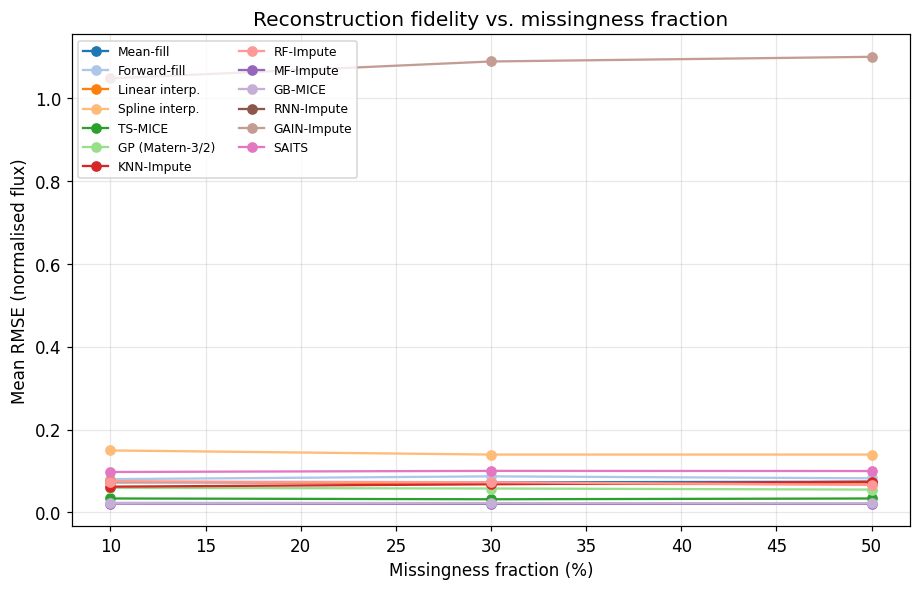

In [29]:
# ---- Figure: RMSE vs missingness fraction, one line per method ----
ok_df = results_df[results_df.status == "ok"]
pivot_rmse = ok_df.groupby(["method", "fraction"])["rmse"].mean().unstack("fraction")
pivot_rmse = pivot_rmse.reindex(METHOD_NAMES)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
cmap = plt.get_cmap("tab10" if len(METHOD_NAMES) <= 10 else "tab20")
for i, m in enumerate(METHOD_NAMES):
    if m in pivot_rmse.index:
        ax.plot(pivot_rmse.columns * 100, pivot_rmse.loc[m], marker="o", label=m,
                color=cmap(i % cmap.N))
ax.set_xlabel("Missingness fraction (%)")
ax.set_ylabel("Mean RMSE (normalised flux)")
ax.set_title("Reconstruction fidelity vs. missingness fraction")
ax.legend(fontsize=8, ncol=2, loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "rmse_vs_missingness.png", dpi=150)
plt.show()


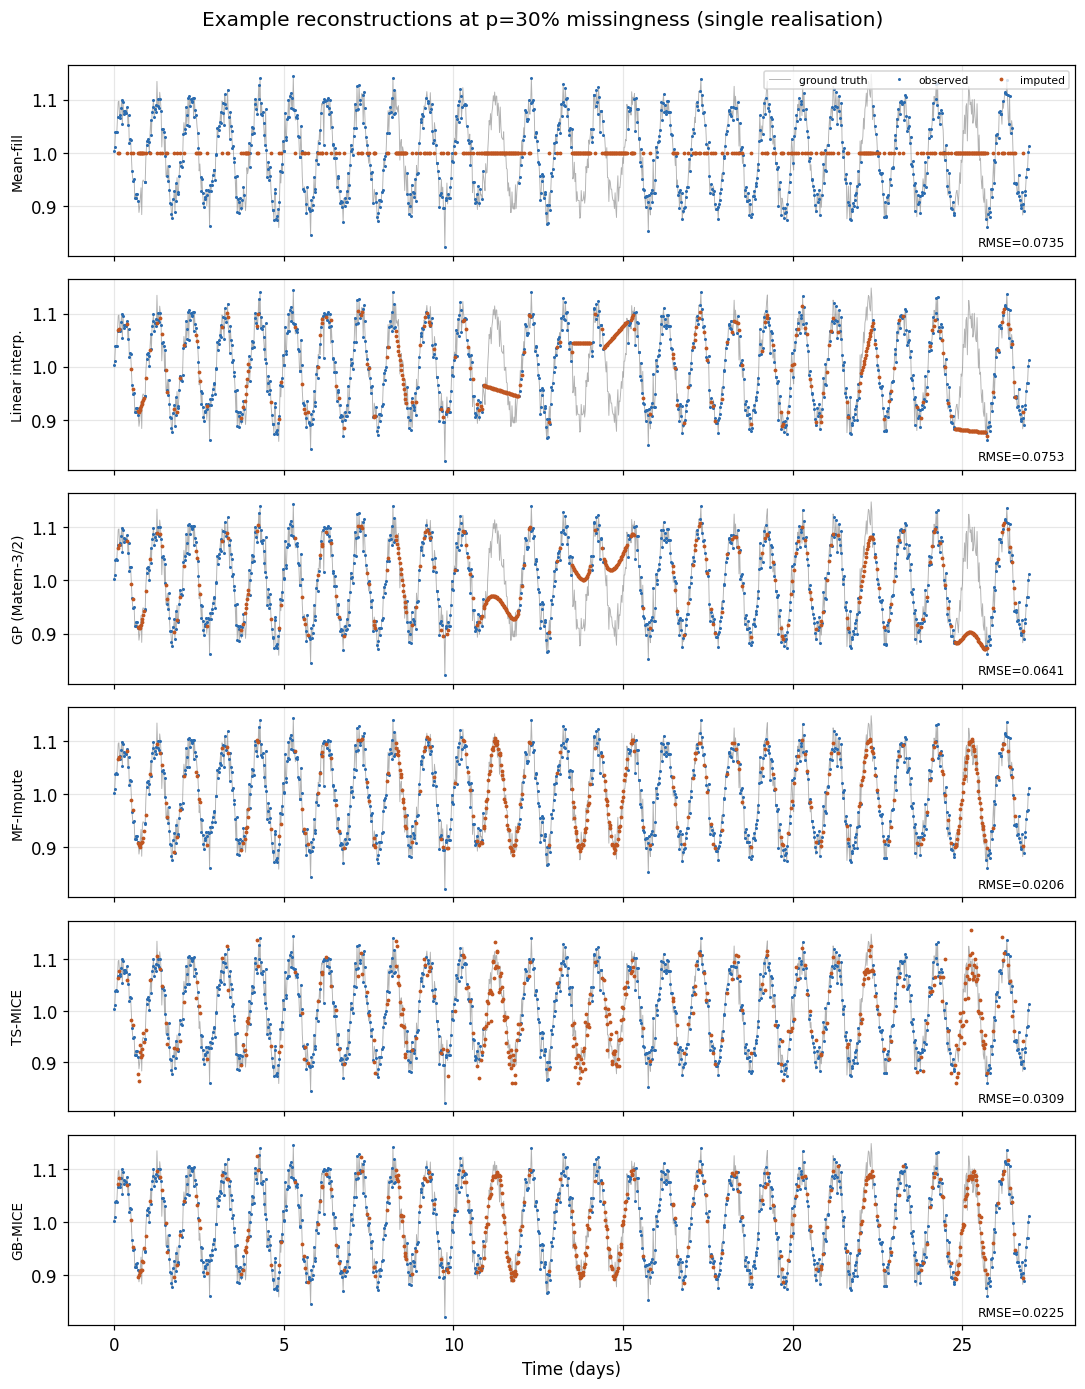

In [30]:
# ---- Figure: example reconstructions on one realisation ----
demo_methods = [m for m in ["Mean-fill", "Linear interp.", "GP (Matern-3/2)", "MF-Impute",
                             "TS-MICE", "GB-MICE"] if m in METHOD_REGISTRY][:6]
demo_p = 0.30
demo_gapped2, demo_idx2, demo_true2, demo_mask2 = inject_gaps(
    f_full, demo_p, block_ratio=BLOCK_RATIO, seed=1)
demo_period_est2 = lomb_scargle_period(t_full[demo_mask2 == 1], demo_gapped2[demo_mask2 == 1])

n_methods_plot = len(demo_methods)
fig, axes = plt.subplots(n_methods_plot, 1, figsize=(10, 2.1 * n_methods_plot), sharex=True)
if n_methods_plot == 1:
    axes = [axes]
for ax, name in zip(axes, demo_methods):
    fn = METHOD_REGISTRY[name]
    out = fn(t_full, demo_gapped2, demo_mask2, demo_period_est2, seed=1)
    f_hat = out[0] if isinstance(out, tuple) else out
    rmse = compute_rmse(f_hat[demo_idx2], demo_true2)
    ax.plot(t_full, f_full, "-", lw=0.6, color="grey", alpha=0.6, label="ground truth")
    ax.plot(t_full[demo_mask2 == 1], demo_gapped2[demo_mask2 == 1], ".", ms=2, color="#2b6cb0",
            label="observed")
    ax.plot(t_full[demo_idx2], f_hat[demo_idx2], ".", ms=3, color="#c05621", label="imputed")
    ax.set_ylabel(name, fontsize=9)
    ax.text(0.99, 0.05, f"RMSE={rmse:.4f}", transform=ax.transAxes, ha="right", fontsize=8)
axes[0].legend(fontsize=7, loc="upper right", ncol=3)
axes[-1].set_xlabel("Time (days)")
fig.suptitle(f"Example reconstructions at p={demo_p:.0%} missingness (single realisation)", y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / "example_reconstructions.png", dpi=150)
plt.show()


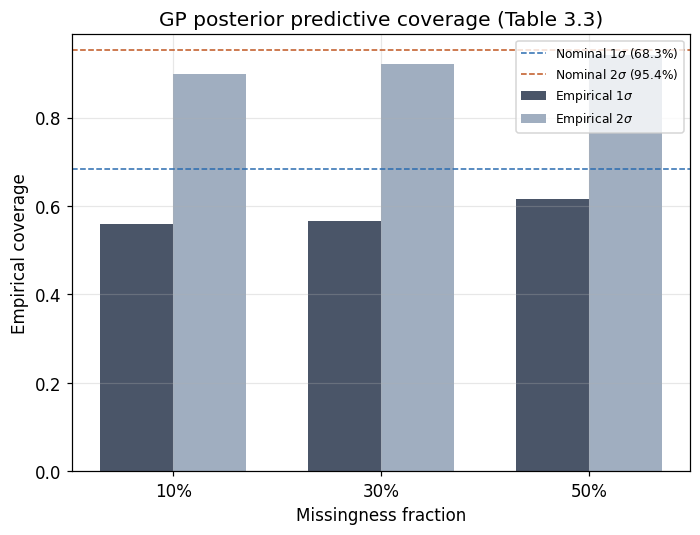

In [31]:
# ---- Figure: GP posterior calibration, if GP is in the registry ----
if "GP (Matern-3/2)" in METHOD_REGISTRY and not table_3_3.empty:
    fig, ax = plt.subplots(figsize=(6.5, 5))
    nominal = [0.683, 0.954]
    x = np.arange(len(MISSING_FRACTIONS))
    width = 0.35
    gp_ok = results_df[(results_df.method == "GP (Matern-3/2)") & (results_df.status == "ok")]
    cov1 = gp_ok.groupby("fraction")["gp_cov_1sigma"].mean().reindex(MISSING_FRACTIONS)
    cov2 = gp_ok.groupby("fraction")["gp_cov_2sigma"].mean().reindex(MISSING_FRACTIONS)
    ax.bar(x - width / 2, cov1, width, label="Empirical 1$\\sigma$", color="#4a5568")
    ax.bar(x + width / 2, cov2, width, label="Empirical 2$\\sigma$", color="#a0aec0")
    ax.axhline(nominal[0], color="#2b6cb0", ls="--", lw=1, label="Nominal 1$\\sigma$ (68.3%)")
    ax.axhline(nominal[1], color="#c05621", ls="--", lw=1, label="Nominal 2$\\sigma$ (95.4%)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{f:.0%}" for f in MISSING_FRACTIONS])
    ax.set_xlabel("Missingness fraction")
    ax.set_ylabel("Empirical coverage")
    ax.set_title("GP posterior predictive coverage (Table 3.3)")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "gp_calibration.png", dpi=150)
    plt.show()
else:
    print("GP not available / no calibration data -- skipping calibration figure.")


## 19. Summary and Output Files

All tables and figures generated for the Chapter 3 analysis are saved in:

- `outputs/tables/`
- `outputs/figures/`

The file `results_raw.csv` contains the results from each individual experiment run and serves as the underlying dataset used to generate the summary tables and statistical analyses.

In [32]:
print("Tables written:")
for p in sorted(TAB_DIR.glob("*.csv")):
    print(" -", p)
print("\nFigures written:")
for p in sorted(FIG_DIR.glob("*.png")):
    print(" -", p)

print(f"\nQUICK_RUN = {QUICK_RUN}")
if QUICK_RUN:
    print("This run used the QUICK_RUN configuration (reduced seeds / epochs) to validate the "
          "pipeline end-to-end. Set QUICK_RUN = False in Section 2 and re-run the notebook for "
          "the exact thesis-scale results (S=30 seeds, full epoch budgets).")

print("\nFive methods selected for the Chapter 4 TESS validation stage (Table 3.1):")
print(", ".join(selected_methods))


Tables written:
 - outputs/tables/ablation_raw.csv
 - outputs/tables/results_raw.csv
 - outputs/tables/table_3_10_scenarios.csv
 - outputs/tables/table_3_1_method_selection.csv
 - outputs/tables/table_3_2_rmse_mae.csv
 - outputs/tables/table_3_3_gp_calibration.csv
 - outputs/tables/table_3_4_period_recovery.csv
 - outputs/tables/table_3_5_amplitude_phase.csv
 - outputs/tables/table_3_6_friedman.csv
 - outputs/tables/table_3_7_nemenyi_30pct.csv
 - outputs/tables/table_3_8_ablation.csv
 - outputs/tables/table_3_9_computational_cost.csv

Figures written:
 - outputs/figures/example_reconstructions.png
 - outputs/figures/fig2_1_clean_vs_gapped.png
 - outputs/figures/fig2_1_top_clean_signal.png
 - outputs/figures/gp_calibration.png
 - outputs/figures/rmse_vs_missingness.png
 - outputs/figures/sanity_check_rmse.png

QUICK_RUN = True
This run used the QUICK_RUN configuration (reduced seeds / epochs) to validate the pipeline end-to-end. Set QUICK_RUN = False in Section 2 and re-run the notebook